# NPFS com BRKGA-Fuzzy
Todos os gráficos e CSVs gerados são salvos automaticamente numa pasta
(`PASTA_SAIDA`, definida na configuração)

**Estrutura:**
1. Instalação e configuração
2. Módulos do projeto (engine, BRKGA, métricas, fuzzy, Optuna)

3. Estudo de caso: uma instância, passo a passo (fixo → métricas → fuzzy → Optuna → comparação final)
4. Diagnóstico opcional de uma semente específica
5. Experimentos com várias instâncias (desligado por padrão — ligue na configuração quando quiser rodar)


## 1. Instalação

In [4]:
!pip install -q pymoo scikit-fuzzy optuna

## 2. Configuração

Depois de mudar algo aqui, rode "Ambiente de execução → Executar tudo" de novo.


In [5]:
# ============================================================
# CONFIGURAÇÃO GERAL — edite aqui, o resto do notebook usa essas variáveis
# ============================================================
import os

# --- Arquivos ---
CAMINHO_ZIP = "/content/Small.zip"          # caminho do zip com as instâncias
NOME_INSTANCIA = "Small/I_2_16_5_1.txt"     # instância do estudo de caso (seções 3 e 4)
PASTA_SAIDA = "/content/resultados_npfs"    # gráficos e CSVs são salvos aqui

# --- BRKGA "de fábrica" (fixo_default) ---

POP_SIZE = 100

P_ELITES_DEFAULT = 0.20
P_OFFSPRINGS_DEFAULT = 0.70
P_MUTANTS_DEFAULT = 0.10

BIAS_DEFAULT = 0.7


# Validação das proporções
assert abs(
    P_ELITES_DEFAULT
    + P_OFFSPRINGS_DEFAULT
    + P_MUTANTS_DEFAULT
    - 1.0
) < 1e-9, "As proporções da população devem somar 1.0"


# Quantidades
N_ELITES_DEFAULT = round(POP_SIZE * P_ELITES_DEFAULT)
N_MUTANTS_DEFAULT = round(POP_SIZE * P_MUTANTS_DEFAULT)
N_OFFSPRINGS_DEFAULT = POP_SIZE - N_ELITES_DEFAULT - N_MUTANTS_DEFAULT

# --- Limites de segurança dos controladores fuzzy (fração da população) ---
FRAC_ELITES_MIN, FRAC_ELITES_MAX = 0.05, 0.40
FRAC_MUTANTES_MIN, FRAC_MUTANTES_MAX = 0.05, 0.40
FRAC_OFFSPRINGS_MIN = 0.20

# --- Estudo de caso (seção 3): uma instância, análise detalhada ---
N_GEN_CASO = 100          # gerações usadas em todas as execuções do estudo de caso
SEED_CASO = 1             # semente usada nas execuções de demonstração (fixo x fuzzy placeholder)

# --- Optuna: tuning + calibração da referência (seção 3.4) ---
N_TRIALS_OPTUNA = 30
N_SEEDS_BUSCA = 3         # sementes usadas durante a busca (média por trial)
N_SEEDS_VALIDACAO = 3     # sementes usadas para calibrar a referência (trajetória média)

# --- Comparação final: fixo_default vs fixo_optuna vs fuzzy (seção 3.5) ---
N_SEEDS_COMPARACAO = 10          # aumente para mais confiança estatística (mais lento)
SEED_COMPARACAO_INICIO = 100     # sementes usadas: range(INICIO, INICIO + N_SEEDS_COMPARACAO)

# --- Diagnóstico de uma semente específica (seção 4, opcional) ---
DIAGNOSTICO_SEED = None   # coloque um número (ex.: 33) para investigar uma execução específica, ou None para pular

# --- Experimentos com várias instâncias (seção 5) ---
RODAR_EXPERIMENTOS_MULTINSTANCIA = False  # mude para True quando quiser rodar (pode demorar bastante)
N_INSTANCIAS_EXPERIMENTO = 5               # quantas instâncias testar (escolhidas automaticamente, espalhadas por tamanho)
N_GEN_EXPERIMENTO = 100
N_SEEDS_EXPERIMENTO = 5
N_TRIALS_OPTUNA_EXPERIMENTO = 15
N_SEEDS_OPTUNA_EXPERIMENTO = 2
SEED_SELECAO_INSTANCIAS = 0                # controla quais instâncias são sorteadas (mesma seed = mesma amostra)

os.makedirs(PASTA_SAIDA, exist_ok=True)
print(f"Pasta de saída: {PASTA_SAIDA}")
print(f"População total (fixo_default): {POP_SIZE} ({N_ELITES_DEFAULT} elites, {N_OFFSPRINGS_DEFAULT} offsprings, {N_MUTANTS_DEFAULT} mutantes)")


Pasta de saída: /content/resultados_npfs
População total (fixo_default): 100 (20 elites, 70 offsprings, 10 mutantes)


## 3. Módulos do projeto



### 3.1 `FlowShopEngine`

Leitura de instâncias e avaliação do makespan

In [ ]:
import os
import numpy as np


class FlowShopEngine:  # VERSÃO UNIFICADA TARDINESS + MAKESPAN (corrigida)
    def __init__(self, n_jobs, n_machines, proc_times, due_dates):
        """
        Engine unificada para problemas de Flow Shop.
        proc_times: Matriz (n_jobs, n_machines)
        due_dates: Vetor (n_jobs)
        """
        self.n_jobs = n_jobs
        self.n_machines = n_machines
        self.proc_times = proc_times
        self.due_dates = due_dates
        self.cfo_count = 0

    def carregar_instancia_txt(self, caminho_arquivo):
        if not os.path.exists(caminho_arquivo):
            np.random.seed(42)
            n, m = 50, 2
            p_matrix = np.random.randint(10, 100, size=(n, m))
            due_dates = np.random.randint(100, 500, size=n)
            return n, m, p_matrix, due_dates

        try:
            with open(caminho_arquivo, 'r') as f:
                linhas = [linha.strip() for list_linhas in f if (linha := list_linhas.strip())]

            num_jobs, num_machines = map(int, linhas[0].split())
            p_matrix = np.zeros((num_jobs, num_machines), dtype=int)

            idx_linha = 2
            for j in range(num_jobs):
                partes = linhas[idx_linha].split()
                for i in range(0, len(partes), 2):
                    maq = int(partes[i])
                    tempo = int(partes[i + 1])
                    p_matrix[j, maq] = tempo
                idx_linha += 1

            while idx_linha < len(linhas) and linhas[idx_linha].lower() != 'duedate':
                idx_linha += 1

            idx_linha += 1
            due_dates = []
            for _ in range(num_jobs):
                due_dates.append(int(linhas[idx_linha]))
                idx_linha += 1

            return num_jobs, num_machines, p_matrix, np.array(due_dates)
        except Exception as e:
            print(f"[ERRO PARSER] Falha ao ler {caminho_arquivo}: {e}. Usando dados simulados.")
            np.random.seed(42)
            return 50, 2, np.random.randint(10, 100, size=(50, 2)), np.random.randint(100, 500, size=50)

    def calcular_lower_bound_potts(self, num_jobs, num_machines, p_matrix, due_dates):
        max_lateness_global = -float('inf')

        for m in range(num_machines):
            if m > 0:
                r_m = np.sum(p_matrix[:, :m], axis=1)
            else:
                r_m = np.zeros(num_jobs)

            if m < num_machines - 1:
                tempo_posterior = np.sum(p_matrix[:, m + 1:], axis=1)
                d_m = due_dates - tempo_posterior
            else:
                d_m = due_dates.copy()

            p_m = p_matrix[:, m].astype(float)
            rem_p = p_m.copy()
            t = 0.0
            lateness_maquina = -float('inf')

            while np.sum(rem_p > 0) > 0:
                jobs_disponiveis = (r_m <= t) & (rem_p > 0)

                if not np.any(jobs_disponiveis):
                    proximas_liberacoes = r_m[(r_m > t) & (rem_p > 0)]
                    t = np.min(proximas_liberacoes)
                    continue

                indices_validos = np.where(jobs_disponiveis)[0]
                job_escolhido = indices_validos[np.argmin(d_m[indices_validos])]

                proximas_liberacoes = r_m[(r_m > t) & (rem_p > 0)]
                if len(proximas_liberacoes) > 0:
                    prox_release_evento = np.min(proximas_liberacoes)
                else:
                    prox_release_evento = float('inf')

                tempo_ate_terminar = rem_p[job_escolhido]
                tempo_ate_interrupcao = prox_release_evento - t
                delta_t = min(tempo_ate_terminar, tempo_ate_interrupcao)

                t += delta_t
                rem_p[job_escolhido] -= delta_t

                if rem_p[job_escolhido] <= 1e-7:
                    lateness_j = t - d_m[job_escolhido]
                    if lateness_j > lateness_maquina:
                        lateness_maquina = lateness_j

            if lateness_maquina > max_lateness_global:
                max_lateness_global = lateness_maquina

        return float(max_lateness_global)

    def bucket_sort_decode(self, keys):
        """Traduz chaves contínuas [0,1] em uma permutação de jobs."""
        return np.argsort(keys)

    def evaluate(self, keys, mode="PFS", objective="Tardiness"):
        self.cfo_count += 1
        n, m = self.n_jobs, self.n_machines

        # 1. Decodificação
        if mode == "PFS":
            seq = self.bucket_sort_decode(keys[:n])
            sequences = [seq] * m
        else:
            sequences = []
            for i in range(m):
                sequences.append(self.bucket_sort_decode(keys[i * n:(i + 1) * n]))

        # 2. Cálculo das matrizes de tempo (Finish Times)
        finish_times = np.zeros((m, n))

        # Primeira máquina (i=0)
        current_time = 0
        for job_idx in sequences[0]:
            current_time += self.proc_times[job_idx, 0]
            finish_times[0, job_idx] = current_time

        # Máquinas subsequentes (i=1 a m-1)
        for i in range(1, m):
            time_on_m = 0
            for job_idx in sequences[i]:
                start = max(time_on_m, finish_times[i - 1, job_idx])
                finish_times[i, job_idx] = start + self.proc_times[job_idx, i]
                time_on_m = finish_times[i, job_idx]

        # 3. Retorno do Objetivo
        if objective == "Makespan":
            return np.max(finish_times[m - 1, :])

        elif objective == "Tardiness":
            tardiness = np.maximum(0, finish_times[m - 1, :] - self.due_dates)
            return np.sum(tardiness)

    def evaluate_with_permutation(self, permutation, objective="Tardiness"):
        self.cfo_count += 1
        n, m = self.n_jobs, self.n_machines

        sequences = [permutation] * m
        finish_times = np.zeros((m, n))

        current_time = 0
        for job_idx in sequences[0]:
            current_time += self.proc_times[job_idx, 0]
            finish_times[0, job_idx] = current_time

        for i in range(1, m):
            time_on_m = 0
            for job_idx in sequences[i]:
                start = max(time_on_m, finish_times[i - 1, job_idx])
                finish_times[i, job_idx] = start + self.proc_times[job_idx, i]
                time_on_m = finish_times[i, job_idx]

        if objective == "Makespan":
            return np.max(finish_times[m - 1, :])

        elif objective == "Tardiness":
            tardiness = np.maximum(0, finish_times[m - 1, :] - self.due_dates)
            return np.sum(tardiness)


### 3.2 Leitura de instâncias dentro de um `.zip`

In [ ]:
import os
import zipfile
import tempfile

def listar_instancias_zip(caminho_zip):
    """Retorna a lista de arquivos .txt disponíveis dentro do ZIP."""
    with zipfile.ZipFile(caminho_zip, 'r') as z:
        return [n for n in z.namelist() if n.lower().endswith('.txt')]


def carregar_instancia_de_zip(caminho_zip, nome_arquivo):
    """
    Extrai `nome_arquivo` de dentro do ZIP para um arquivo temporário e
    usa o parser oficial (FlowShopEngine.carregar_instancia_txt) para lê-lo.

    Retorna: (n_jobs, n_machines, proc_times, due_dates)
    """
    with zipfile.ZipFile(caminho_zip, 'r') as z:
        if nome_arquivo not in z.namelist():
            raise FileNotFoundError(
                f"'{nome_arquivo}' não encontrado no ZIP. "
                f"Disponíveis: {listar_instancias_zip(caminho_zip)}"
            )
        conteudo = z.read(nome_arquivo)

    with tempfile.NamedTemporaryFile(mode='wb', suffix='.txt', delete=False) as tmp:
        tmp.write(conteudo)
        tmp_path = tmp.name

    try:
        # Instância "vazia" só para poder chamar o método (ele não usa
        # nenhum atributo de self, apenas precisa ser um método de instância).
        engine_tmp = FlowShopEngine(0, 0, None, None)
        n_jobs, n_machines, proc_times, due_dates = engine_tmp.carregar_instancia_txt(tmp_path)
    finally:
        os.remove(tmp_path)

    return n_jobs, n_machines, proc_times, due_dates


def montar_engine_de_zip(caminho_zip, nome_arquivo):
    """Atalho: lê a instância do zip e já devolve a FlowShopEngine pronta."""
    n_jobs, n_machines, proc_times, due_dates = carregar_instancia_de_zip(caminho_zip, nome_arquivo)
    engine = FlowShopEngine(n_jobs, n_machines, proc_times, due_dates)
    return engine


### 3.3 Problema NPFS no `pymoo` + BRKGA fixo

In [ ]:
import numpy as np

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.soo.nonconvex.brkga import BRKGA
from pymoo.optimize import minimize
from pymoo.termination import get_termination

class NPFSProblem(ElementwiseProblem):
    """
    Wrapper pymoo para o problema NPFS.
    n_var = n_jobs * n_machines  (um bloco de n_jobs chaves por máquina).
    """

    def __init__(self, engine: FlowShopEngine):
        self.engine = engine
        n_var = engine.n_jobs * engine.n_machines
        super().__init__(n_var=n_var, n_obj=1, n_constr=0, xl=0.0, xu=1.0)

    def _evaluate(self, x, out, *args, **kwargs):
        makespan = self.engine.evaluate(x, mode="NPFS", objective="Makespan")
        out["F"] = np.array([makespan])


def run_brkga_fixo(
    engine: FlowShopEngine,
    n_gen=200,
    seed=1,
    n_elites=20,
    n_offsprings=70,
    n_mutants=10,
    bias=0.7,
    verbose=False,
):
    """
    Executa o BRKGA com parâmetros fixos no modo NPFS.

    População total = n_elites + n_offsprings + n_mutants (regra padrão do BRKGA).

    Retorna:
      result       -> objeto Result do pymoo (result.X, result.F = melhor solução/ makespan)
      historico    -> lista de dicts por geração: {"gen": g, "best_makespan": ..., "pop_X": array}
    """
    problem = NPFSProblem(engine)

    algorithm = BRKGA(
        n_elites=n_elites,
        n_offsprings=n_offsprings,
        n_mutants=n_mutants,
        bias=bias,
        eliminate_duplicates=True,
    )

    termination = get_termination("n_gen", n_gen)

    result = minimize(
        problem,
        algorithm,
        termination,
        seed=seed,
        save_history=True,
        verbose=verbose,
    )

    historico = []
    for g, algo_estado in enumerate(result.history):
        pop = algo_estado.pop
        F = pop.get("F").flatten()
        historico.append({
            "gen": g,
            "best_makespan": float(F.min()),
            "pop_X": pop.get("X").copy(),  # cromossomos da geração (para diversidade, na próxima etapa)
        })

    return result, historico


### 3.4 Métricas: diversidade, qualidade, erro e variação do erro

In [9]:
# -*- coding: utf-8 -*-
"""
Métricas por geração para os controladores fuzzy (etapa 2).

Reaproveita o `historico` já produzido por `run_brkga_fixo` (que guarda
`pop_X`, os cromossomos de cada geração, e `best_makespan`). Não é
necessário alterar o loop do BRKGA: tudo aqui é calculado como pós-processamento
sobre o histórico salvo.

Diversidade
-----------
Para cada par de indivíduos, calcula-se a média das diferenças absolutas
entre suas chaves. Depois, a diversidade da geração é a média dessas
distâncias entre todos os pares da população.

    diversidade(g) = média_{i<j} [ média_k |x_i,k - x_j,k| ]

Quanto maior, mais "espalhada" está a população nas chaves (mais diversidade
genética); quanto menor, mais convergida/uniforme.

Qualidade
---------
Medida em relação ao melhor makespan da primeira geração (referência inicial):

    qualidade(g) = (Cmax_best(0) - Cmax_best(g)) / Cmax_best(0)

Na geração 0, qualidade(0) = 0, porque ainda não houve melhoria em relação
à primeira geração. Conforme o BRKGA é elitista, Cmax_best(g) <= Cmax_best(0)
sempre, então qualidade(g) >= 0 e cresce conforme o makespan melhora.

Erro e variação do erro
------------------------
    erro(g)        = referência(g) - valor(g)
    variação_erro(g) = erro(g) - erro(g-1)

`referência` pode ser um número fixo OU uma função `gen -> valor`, o que
permite mudar a referência no meio de uma execução (exigido na especificação,
para testar se os controladores fuzzy acompanham a mudança). As referências
definitivas (baseadas em execuções de análise com Optuna) ainda não foram
definidas — por enquanto usamos um valor fixo configurável como placeholder,
deixado explícito no código para não ser confundido com um valor "oficial".
"""

import numpy as np
from scipy.spatial.distance import pdist


def calcular_diversidade(pop_X):
    """
    pop_X: array (pop_size, n_var) com os cromossomos da geração.
    Retorna a diversidade média entre todos os pares (float).
    """
    if pop_X.shape[0] < 2:
        return 0.0
    # pdist(..., 'cityblock') dá, para cada par, a SOMA das diferenças absolutas.
    # Dividindo por n_var, vira a MÉDIA das diferenças absolutas por chave,
    # exatamente como pedido na especificação.
    distancias_soma_abs = pdist(pop_X, metric='cityblock')
    n_var = pop_X.shape[1]
    distancias_media_abs = distancias_soma_abs / n_var
    return float(distancias_media_abs.mean())


def calcular_qualidade(best_makespan_gen, best_makespan_gen0):
    """qualidade(g) = (Cmax_best(0) - Cmax_best(g)) / Cmax_best(0)"""
    if best_makespan_gen0 == 0:
        return 0.0
    return float((best_makespan_gen0 - best_makespan_gen) / best_makespan_gen0)


def _resolver_referencia(referencia, gen):
    """Aceita um valor fixo (int/float) ou uma função gen -> valor."""
    if callable(referencia):
        return float(referencia(gen))
    return float(referencia)


def computar_metricas(historico, ref_diversidade=0.20, ref_qualidade=0.10):
    """
    Recebe o `historico` de `run_brkga_fixo` (lista de dicts com
    'gen', 'best_makespan', 'pop_X') e devolve uma lista de dicts,
    um por geração, com todas as métricas para os controladores fuzzy:

        gen, best_makespan,
        diversidade, qualidade,
        erro_diversidade, variacao_erro_diversidade,
        erro_qualidade, variacao_erro_qualidade,
        ref_diversidade, ref_qualidade   (registradas para conferência/plot)

    ref_diversidade / ref_qualidade: valor fixo OU função `gen -> valor`,
    permitindo alterar a referência durante a execução.

    IMPORTANTE: os valores padrão (0.20 e 0.10) são placeholders para
    validar o pipeline. As referências definitivas virão da análise das
    execuções com Optuna, conforme a especificação do projeto.
    """
    metricas = []
    best_makespan_gen0 = historico[0]["best_makespan"]

    erro_diversidade_anterior = None
    erro_qualidade_anterior = None

    for entrada in historico:
        gen = entrada["gen"]
        best_makespan = entrada["best_makespan"]
        pop_X = entrada["pop_X"]

        diversidade = calcular_diversidade(pop_X)
        qualidade = calcular_qualidade(best_makespan, best_makespan_gen0)

        ref_div_g = _resolver_referencia(ref_diversidade, gen)
        ref_qual_g = _resolver_referencia(ref_qualidade, gen)

        erro_diversidade = ref_div_g - diversidade
        erro_qualidade = ref_qual_g - qualidade

        variacao_erro_diversidade = (
            0.0 if erro_diversidade_anterior is None
            else erro_diversidade - erro_diversidade_anterior
        )
        variacao_erro_qualidade = (
            0.0 if erro_qualidade_anterior is None
            else erro_qualidade - erro_qualidade_anterior
        )

        metricas.append({
            "gen": gen,
            "best_makespan": best_makespan,
            "diversidade": diversidade,
            "qualidade": qualidade,
            "erro_diversidade": erro_diversidade,
            "variacao_erro_diversidade": variacao_erro_diversidade,
            "erro_qualidade": erro_qualidade,
            "variacao_erro_qualidade": variacao_erro_qualidade,
            "ref_diversidade": ref_div_g,
            "ref_qualidade": ref_qual_g,
        })

        erro_diversidade_anterior = erro_diversidade
        erro_qualidade_anterior = erro_qualidade

    return metricas


def metricas_para_csv(metricas, caminho_csv):
    """Salva o log de métricas por geração em CSV (útil para os experimentos futuros)."""
    import csv
    campos = list(metricas[0].keys())
    with open(caminho_csv, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=campos)
        writer.writeheader()
        writer.writerows(metricas)


### 3.5 Controladores fuzzy (Mamdani, erro + Δerro)

In [10]:
# -*- coding: utf-8 -*-
"""
Controladores fuzzy (etapa 3).

Dois controladores independentes, ambos do tipo clássico "erro + variação do
erro" (Mamdani, 5 termos linguísticos: NB, NS, Z, PS, PB), usando scikit-fuzzy.


  - Controlador de DIVERSIDADE: entradas = erro_diversidade e
    variacao_erro_diversidade; saída = ajuste na PROPORÇÃO DE MUTANTES
    do BRKGA. Mais mutantes = mais exploração = mais diversidade.

  - Controlador de QUALIDADE: entradas = erro_qualidade e
    variacao_erro_qualidade; saída = ajuste na PROPORÇÃO DE ELITES
    do BRKGA. Mais elites = mais pressão de exploração/seleção = tende
    a melhorar a qualidade (mais elitismo), à custa de diversidade.

Essa escolha mantém os dois controladores atuando em "botões" diferentes
do BRKGA (mutantes vs. elites), com a fração de offsprings absorvendo o
que sobra, para o tamanho da população se manter constante.

Interpretação das saídas (ambos os controladores):
  - saída positiva -> aumentar a proporção correspondente (mais mutantes /
    mais elites), porque o erro indica que o valor atual está abaixo da
    referência.
  - saída negativa -> diminuir a proporção correspondente, porque o valor
    atual já está acima da referência.
"""

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl


# Tabela de regras de um controlador fuzzy PD (erro x variação do erro ->
# saída), gerada por fórmula (em vez de escrita manualmente) para garantir
# a direção correta: a saída segue o SINAL do erro (erro positivo -> saída
# positiva, ou seja, "aumentar" quando o valor está abaixo da referência),
# e a variação do erro modula (antecipa) a intensidade da correção.
_CATEGORIAS = ['NB', 'NS', 'Z', 'PS', 'PB']
_NUM = {'NB': -2, 'NS': -1, 'Z': 0, 'PS': 1, 'PB': 2}
_CAT = {v: k for k, v in _NUM.items()}
_PESO_DELTA = 0.4  # quanto a tendência (variação do erro) pesa em relação ao erro


def _saida_categoria(e_cat, de_cat):
    score = _NUM[e_cat] + _PESO_DELTA * _NUM[de_cat]
    score = max(-2, min(2, round(score)))
    return _CAT[score]


_TABELA_REGRAS = {
    (e_cat, de_cat): _saida_categoria(e_cat, de_cat)
    for e_cat in _CATEGORIAS
    for de_cat in _CATEGORIAS
}


def _adicionar_termos_5niveis(variavel):
    """Cria 5 funções de pertinência triangulares (NB, NS, Z, PS, PB) cobrindo
    todo o universo da variável, com sobreposição de 50% (formato clássico)."""
    lo, hi = variavel.universe[0], variavel.universe[-1]
    meio = (lo + hi) / 2
    q1 = lo + (hi - lo) * 0.25
    q3 = lo + (hi - lo) * 0.75

    variavel['NB'] = fuzz.trimf(variavel.universe, [lo, lo, meio])
    variavel['NS'] = fuzz.trimf(variavel.universe, [lo, q1, meio])
    variavel['Z'] = fuzz.trimf(variavel.universe, [q1, meio, q3])
    variavel['PS'] = fuzz.trimf(variavel.universe, [meio, q3, hi])
    variavel['PB'] = fuzz.trimf(variavel.universe, [meio, hi, hi])


class ControladorFuzzyPD:
    """
    Controlador fuzzy genérico do tipo erro + variação do erro -> saída.
    Usado tanto para diversidade quanto para qualidade (com universos e
    faixas de saída diferentes para cada um).
    """

    def __init__(self, nome, erro_range, delta_erro_range, saida_range, n_pontos=201):
        self.nome = nome
        self._erro_range = erro_range
        self._delta_erro_range = delta_erro_range
        self._saida_range = saida_range

        e_universe = np.linspace(erro_range[0], erro_range[1], n_pontos)
        de_universe = np.linspace(delta_erro_range[0], delta_erro_range[1], n_pontos)
        s_universe = np.linspace(saida_range[0], saida_range[1], n_pontos)

        self.erro = ctrl.Antecedent(e_universe, 'erro')
        self.delta_erro = ctrl.Antecedent(de_universe, 'delta_erro')
        self.saida = ctrl.Consequent(s_universe, 'saida')

        for variavel in (self.erro, self.delta_erro, self.saida):
            _adicionar_termos_5niveis(variavel)

        regras = [
            ctrl.Rule(self.erro[e_cat] & self.delta_erro[de_cat], self.saida[s_cat])
            for (e_cat, de_cat), s_cat in _TABELA_REGRAS.items()
        ]

        self.sistema = ctrl.ControlSystem(regras)
        self.sim = ctrl.ControlSystemSimulation(self.sistema)

    def calcular(self, erro_valor, delta_erro_valor):
        """Recebe erro(g) e variação do erro(g) e devolve o ajuste (saída defuzzificada)."""
        e = float(np.clip(erro_valor, self._erro_range[0], self._erro_range[1]))
        de = float(np.clip(delta_erro_valor, self._delta_erro_range[0], self._delta_erro_range[1]))
        self.sim.input['erro'] = e
        self.sim.input['delta_erro'] = de
        self.sim.compute()
        return float(self.sim.output['saida'])


def criar_controlador_diversidade(
    erro_range=(-0.3, 0.3),
    delta_erro_range=(-0.15, 0.15),
    saida_range=(-0.05, 0.05),
):
    """Saída: ajuste na proporção de mutantes (fração da população)."""
    return ControladorFuzzyPD("diversidade", erro_range, delta_erro_range, saida_range)


def criar_controlador_qualidade(
    erro_range=(-0.3, 0.3),
    delta_erro_range=(-0.15, 0.15),
    saida_range=(-0.05, 0.05),
):
    """Saída: ajuste na proporção de elites (fração da população)."""
    return ControladorFuzzyPD("qualidade", erro_range, delta_erro_range, saida_range)


### 3.6 BRKGA adaptativo (fuzzy)

In [11]:
# -*- coding: utf-8 -*-
"""
BRKGA adaptativo: a cada geração, os controladores fuzzy ajustam a
proporção de mutantes (via erro/delta_erro de diversidade) e a proporção
de elites (via erro/delta_erro de qualidade). A proporção de offsprings
absorve o que sobra, mantendo o tamanho da população constante.

Usa o loop manual do pymoo (`algorithm.setup()` + `algorithm.next()`),
em vez de `minimize()`, porque precisamos alterar `n_elites`/`n_mutantes`/
`n_offsprings` entre uma geração e outra — o que não é possível só com a
API de alto nível.

A avaliação de fitness continua sendo, em todos os casos, a chamada a
`FlowShopEngine.evaluate(mode="NPFS", objective="Makespan")` (via o mesmo
`NPFSProblem` já usado no BRKGA fixo).
"""

import numpy as np

from pymoo.algorithms.soo.nonconvex.brkga import BRKGA
from pymoo.termination import get_termination

def _resolver_referencia(referencia, gen):
    if callable(referencia):
        return float(referencia(gen))
    return float(referencia)


def run_brkga_fuzzy(
    engine: FlowShopEngine,
    n_gen=200,
    seed=1,
    # composição inicial da população (o total é mantido fixo ao longo da execução)
    n_elites0=20,
    n_offsprings0=70,
    n_mutants0=10,
    bias=0.7,
    # limites (fração da população) para evitar que elites/mutantes dominem tudo
    frac_elites_min=0.05,
    frac_elites_max=0.40,
    frac_mutantes_min=0.05,
    frac_mutantes_max=0.40,
    frac_offsprings_min=0.20,
    # referências dos controladores: valor fixo OU função gen -> valor
    ref_diversidade=0.20,
    ref_qualidade=0.10,
    controlador_diversidade=None,
    controlador_qualidade=None,
):
    """
    Executa o BRKGA com os dois controladores fuzzy ativos.

    Retorna:
      result_final -> dict com 'X' (melhor cromossomo) e 'F' (melhor makespan)
      historico    -> lista de dicts por geração, com todas as métricas E os
                      parâmetros do BRKGA usados naquela geração (n_elites,
                      n_mutants, n_offsprings, saída dos dois controladores).
    """
    pop_size = n_elites0 + n_offsprings0 + n_mutants0

    if controlador_diversidade is None:
        controlador_diversidade = criar_controlador_diversidade()
    if controlador_qualidade is None:
        controlador_qualidade = criar_controlador_qualidade()

    problem = NPFSProblem(engine)
    algorithm = BRKGA(
        n_elites=n_elites0,
        n_offsprings=n_offsprings0,
        n_mutants=n_mutants0,
        bias=bias,
        eliminate_duplicates=True,
    )
    termination = get_termination("n_gen", n_gen)
    algorithm.setup(problem, termination=termination, seed=seed, verbose=False)

    historico = []
    best_makespan_gen0 = None
    erro_diversidade_anterior = None
    erro_qualidade_anterior = None

    frac_elites = n_elites0 / pop_size
    frac_mutantes = n_mutants0 / pop_size

    gen = 0
    while algorithm.has_next():
        algorithm.next()

        pop_X = algorithm.pop.get("X")
        pop_F = algorithm.pop.get("F").flatten()
        best_makespan = float(pop_F.min())

        if best_makespan_gen0 is None:
            best_makespan_gen0 = best_makespan

        diversidade = calcular_diversidade(pop_X)
        qualidade = calcular_qualidade(best_makespan, best_makespan_gen0)

        ref_div_g = _resolver_referencia(ref_diversidade, gen)
        ref_qual_g = _resolver_referencia(ref_qualidade, gen)

        erro_diversidade = ref_div_g - diversidade
        erro_qualidade = ref_qual_g - qualidade

        delta_erro_diversidade = (
            0.0 if erro_diversidade_anterior is None
            else erro_diversidade - erro_diversidade_anterior
        )
        delta_erro_qualidade = (
            0.0 if erro_qualidade_anterior is None
            else erro_qualidade - erro_qualidade_anterior
        )

        # --- controladores fuzzy: ajuste nas frações de mutantes e elites ---
        ajuste_mutantes = controlador_diversidade.calcular(erro_diversidade, delta_erro_diversidade)
        ajuste_elites = controlador_qualidade.calcular(erro_qualidade, delta_erro_qualidade)

        frac_mutantes = float(np.clip(frac_mutantes + ajuste_mutantes, frac_mutantes_min, frac_mutantes_max))
        frac_elites = float(np.clip(frac_elites + ajuste_elites, frac_elites_min, frac_elites_max))

        # garante espaço mínimo para offsprings; se elites+mutantes invadirem
        # demais, corta os dois proporcionalmente
        if frac_elites + frac_mutantes > (1 - frac_offsprings_min):
            excesso = (frac_elites + frac_mutantes) - (1 - frac_offsprings_min)
            total = frac_elites + frac_mutantes
            frac_elites -= excesso * (frac_elites / total)
            frac_mutantes -= excesso * (frac_mutantes / total)

        novo_n_elites = max(1, int(round(frac_elites * pop_size)))
        novo_n_mutantes = max(1, int(round(frac_mutantes * pop_size)))
        novo_n_offsprings = pop_size - novo_n_elites - novo_n_mutantes

        # aplica os novos parâmetros na próxima geração do BRKGA
        algorithm.survival.n_elites = novo_n_elites
        algorithm.n_elites = novo_n_elites
        algorithm.n_mutants = novo_n_mutantes
        algorithm.n_offsprings = novo_n_offsprings

        historico.append({
            "gen": gen,
            "best_makespan": best_makespan,
            "diversidade": diversidade,
            "qualidade": qualidade,
            "erro_diversidade": erro_diversidade,
            "variacao_erro_diversidade": delta_erro_diversidade,
            "erro_qualidade": erro_qualidade,
            "variacao_erro_qualidade": delta_erro_qualidade,
            "ref_diversidade": ref_div_g,
            "ref_qualidade": ref_qual_g,
            "ajuste_mutantes": ajuste_mutantes,
            "ajuste_elites": ajuste_elites,
            "n_elites": novo_n_elites,
            "n_mutants": novo_n_mutantes,
            "n_offsprings": novo_n_offsprings,
            "pop_X": pop_X.copy(),
        })

        erro_diversidade_anterior = erro_diversidade
        erro_qualidade_anterior = erro_qualidade
        gen += 1

    result_final = algorithm.result()
    melhor = {"X": result_final.X, "F": float(result_final.F[0])}

    return melhor, historico


### 3.7 Optuna: tuning do BRKGA fixo + calibração das referências

In [12]:
# -*- coding: utf-8 -*-
"""
Etapa 4 — Optuna.

Duas responsabilidades, conforme a especificação:

  1. Rodar o BRKGA FIXO com o Optuna buscando boas configurações
     (proporção de elites, proporção de mutantes, bias). Isso vira o
     baseline "BRKGA + Optuna" nos experimentos comparativos.

  2. Analisar as execuções da melhor configuração encontrada (trajetória
     de diversidade, de qualidade, estabilidade, convergência) para
     derivar REFERÊNCIAS EXPERIMENTAIS (em vez dos placeholders fixos
     usados nas etapas 2 e 3) — como uma curva por geração (média das
     execuções da melhor configuração), não mais um número fixo.

O tamanho total da população é mantido fixo (mesma convenção das etapas
1-3: pop_size = n_elites + n_offsprings + n_mutants); o Optuna otimiza a
FRAÇÃO de elites, a FRAÇÃO de mutantes e o bias — a fração de offsprings
é o que sobra.
"""

import numpy as np
import optuna

def _fracoes_para_contagens(frac_elites, frac_mutantes, pop_size):
    n_elites = max(1, int(round(frac_elites * pop_size)))
    n_mutantes = max(1, int(round(frac_mutantes * pop_size)))
    n_offsprings = max(1, pop_size - n_elites - n_mutantes)
    return n_elites, n_offsprings, n_mutantes


def construir_objetivo(engine, pop_size=100, n_gen=100, seeds=(1, 2, 3)):
    """
    Cria a função-objetivo do Optuna: para cada trial, roda o BRKGA fixo
    com a configuração sugerida em todas as `seeds` e retorna o makespan
    MÉDIO (mais robusto que uma seed só, evita overfitar em uma sorte de RNG).
    """

    def objetivo(trial):
        frac_elites = trial.suggest_float("frac_elites", 0.05, 0.40)
        frac_mutantes = trial.suggest_float("frac_mutantes", 0.05, 0.40)
        bias = trial.suggest_float("bias", 0.40, 0.85)

        # espaço p/ offsprings de pelo menos 20%
        if frac_elites + frac_mutantes > 0.80:
            raise optuna.TrialPruned()

        n_elites, n_offsprings, n_mutantes = _fracoes_para_contagens(frac_elites, frac_mutantes, pop_size)

        makespans = []
        for seed in seeds:
            result, _ = run_brkga_fixo(
                engine, n_gen=n_gen, seed=seed,
                n_elites=n_elites, n_offsprings=n_offsprings, n_mutants=n_mutantes,
                bias=bias,
            )
            makespans.append(result.F[0])

        return float(np.mean(makespans))

    return objetivo


def rodar_optuna(engine, pop_size=100, n_gen=100, seeds=(1, 2, 3), n_trials=30, seed_optuna=0):
    """Executa o estudo Optuna e devolve (study, melhores_parametros_como_contagens)."""
    sampler = optuna.samplers.TPESampler(seed=seed_optuna)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(construir_objetivo(engine, pop_size, n_gen, seeds), n_trials=n_trials, show_progress_bar=False)

    melhores = study.best_params
    n_elites, n_offsprings, n_mutantes = _fracoes_para_contagens(
        melhores["frac_elites"], melhores["frac_mutantes"], pop_size
    )
    melhor_config = {
        "n_elites": n_elites,
        "n_offsprings": n_offsprings,
        "n_mutants": n_mutantes,
        "bias": melhores["bias"],
    }
    return study, melhor_config


def analisar_melhor_configuracao(engine, melhor_config, n_gen=100, seeds=(10, 11, 12, 13, 14)):
    """
    Roda a melhor configuração encontrada pelo Optuna em várias sementes
    (diferentes das usadas na busca, para não vazar dados), calcula as
    métricas de cada execução e devolve:

      - lista de listas de métricas (uma lista de métricas por seed)
      - trajetória MÉDIA de diversidade por geração (curva, não escalar)
      - trajetória MÉDIA de qualidade por geração (curva, não escalar)
      - makespans finais (para estabilidade: média e desvio-padrão)
    """
    todas_metricas = []
    makespans_finais = []

    for seed in seeds:
        result, historico = run_brkga_fixo(
            engine, n_gen=n_gen, seed=seed,
            n_elites=melhor_config["n_elites"],
            n_offsprings=melhor_config["n_offsprings"],
            n_mutants=melhor_config["n_mutants"],
            bias=melhor_config["bias"],
        )
        # ref_diversidade/ref_qualidade aqui não importam: só queremos
        # diversidade e qualidade cruas, não o erro
        metricas = computar_metricas(historico, ref_diversidade=0.0, ref_qualidade=0.0)
        todas_metricas.append(metricas)
        makespans_finais.append(result.F[0])

    n_geracoes = min(len(m) for m in todas_metricas)
    diversidade_matriz = np.array([[m[g]["diversidade"] for g in range(n_geracoes)] for m in todas_metricas])
    qualidade_matriz = np.array([[m[g]["qualidade"] for g in range(n_geracoes)] for m in todas_metricas])

    trajetoria_diversidade = diversidade_matriz.mean(axis=0)
    trajetoria_qualidade = qualidade_matriz.mean(axis=0)

    resumo = {
        "makespan_medio": float(np.mean(makespans_finais)),
        "makespan_desvio_padrao": float(np.std(makespans_finais)),
        "makespans_finais": makespans_finais,
    }

    return todas_metricas, trajetoria_diversidade, trajetoria_qualidade, resumo


def construir_referencia_a_partir_da_trajetoria(trajetoria):
    """
    Transforma uma trajetória (array por geração) em uma referência
    "gen -> valor" utilizável pelos controladores fuzzy (mesmo formato
    aceito por `computar_metricas` e `run_brkga_fuzzy`). Fora do alcance
    de gerações observado, repete o último valor.
    """
    trajetoria = np.asarray(trajetoria)

    def referencia(gen):
        idx = min(gen, len(trajetoria) - 1)
        return float(trajetoria[idx])

    return referencia


## 4. Estudo de caso: a instância configurada em `NOME_INSTANCIA`

Esta seção roda o pipeline completo numa única instância, gera todos os gráficos
principais, e faz a comparação de Cmax entre os 3 métodos (fixo_default, fixo_optuna,
fuzzy). Tudo usando as variáveis definidas na configuração .

### 4.1 Carregando a instância

In [13]:
if os.path.exists(CAMINHO_ZIP):
    engine = montar_engine_de_zip(CAMINHO_ZIP, NOME_INSTANCIA)
    print(f"Instância carregada do zip: {NOME_INSTANCIA}")
else:
    engine_tmp = FlowShopEngine(0, 0, None, None)
    n_jobs, n_machines, proc_times, due_dates = engine_tmp.carregar_instancia_txt("arquivo_inexistente.txt")
    engine = FlowShopEngine(n_jobs, n_machines, proc_times, due_dates)
    print(f"[AVISO] '{CAMINHO_ZIP}' não encontrado — usando instância sintética de teste (fallback).")

print(f"n_jobs = {engine.n_jobs}, n_machines = {engine.n_machines}")

Instância carregada do zip: Small/I_2_16_5_1.txt
n_jobs = 16, n_machines = 5


### 4.2 BRKGA fixo (parâmetros de fábrica) — linha de base

Roda uma vez, com `N_GEN_CASO` gerações e `SEED_CASO`, só para confirmar que o
pipeline básico funciona e ver a curva de convergência.

[fixo_default] melhor makespan: 1499.00


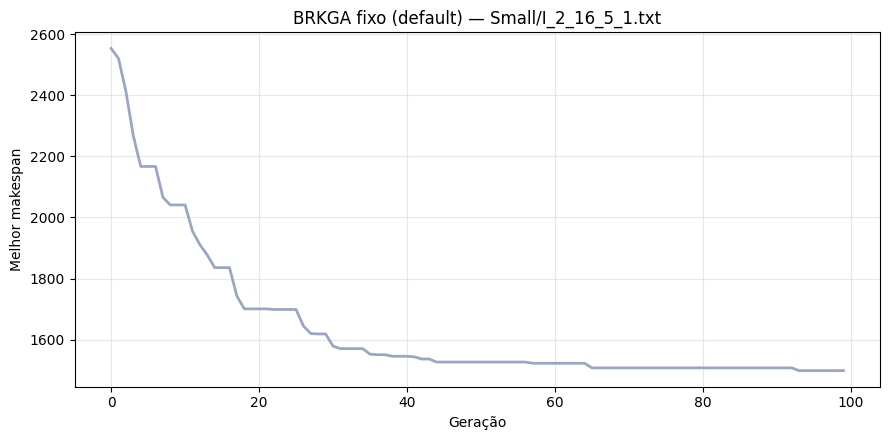

In [14]:
result_fixo, historico_fixo = run_brkga_fixo(
    engine, n_gen=N_GEN_CASO, seed=SEED_CASO,
    n_elites=N_ELITES_DEFAULT, n_offsprings=N_OFFSPRINGS_DEFAULT,
    n_mutants=N_MUTANTS_DEFAULT, bias=BIAS_DEFAULT,
)
print(f"[fixo_default] melhor makespan: {result_fixo.F[0]:.2f}")

import matplotlib.pyplot as plt
gens = [h["gen"] for h in historico_fixo]
plt.figure(figsize=(9, 4.5))
plt.plot(gens, [h["best_makespan"] for h in historico_fixo], color="#9AA6C3", linewidth=2)
plt.xlabel("Geração"); plt.ylabel("Melhor makespan")
plt.title(f"BRKGA fixo (default) — {NOME_INSTANCIA}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/01_convergencia_fixo_default.png", dpi=150)
plt.show()

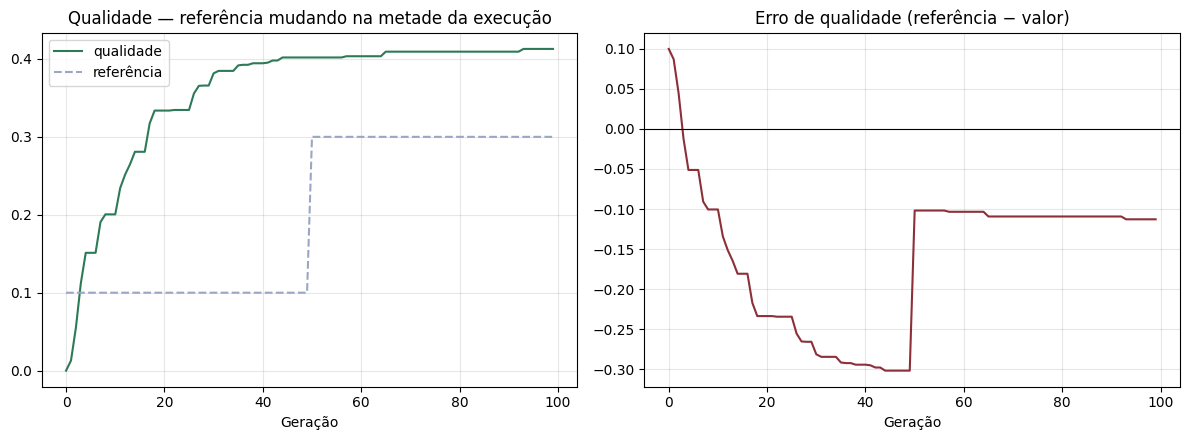

In [15]:
def ref_qualidade_exemplo(gen):
    metade = len(historico_fixo) // 2
    return 0.10 if gen < metade else 0.30   # referência salta na metade da execução

metricas_qualidade_demo = computar_metricas(historico_fixo, ref_diversidade=0.20, ref_qualidade=ref_qualidade_exemplo)

gens_q = [m["gen"] for m in metricas_qualidade_demo]
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].plot(gens_q, [m["qualidade"] for m in metricas_qualidade_demo], color="#2C7A57", label="qualidade")
axs[0].plot(gens_q, [m["ref_qualidade"] for m in metricas_qualidade_demo], "--", color="#9AA6C3", label="referência")
axs[0].set_title("Qualidade — referência mudando na metade da execução")
axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(gens_q, [m["erro_qualidade"] for m in metricas_qualidade_demo], color="#8C2F39")
axs[1].axhline(0, color="black", linewidth=0.8)
axs[1].set_title("Erro de qualidade (referência − valor)")
axs[1].grid(alpha=0.3)
for ax in axs:
    ax.set_xlabel("Geração")
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/12_qualidade_referencia_mudando.png", dpi=150)
plt.show()

### 4.3 Métricas (diversidade, qualidade) dessa execução, com referência placeholder

Geração 0:   diversidade=0.3337  qualidade=0.0000
Última gen:  diversidade=0.1380  qualidade=0.4128


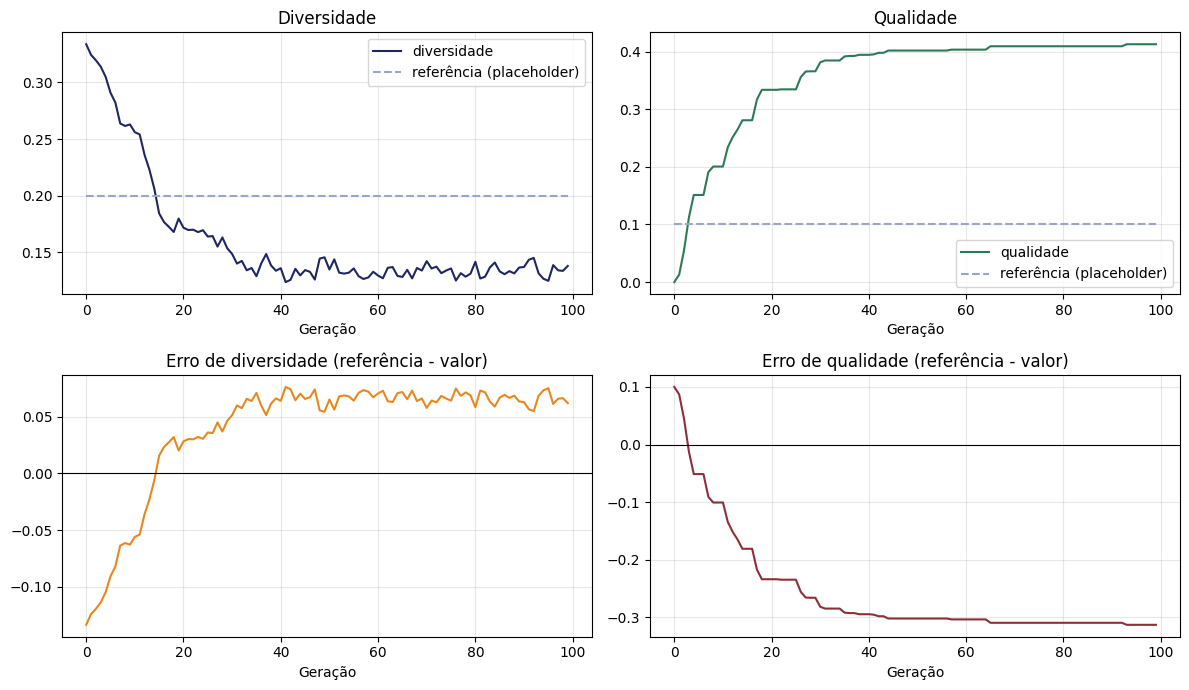

In [16]:
# Placeholder (0.20 / 0.10) — ainda não calibrado com dados reais, só para
# validar o mecanismo de erro/variação do erro antes de usar valores calibrados.
metricas_fixo = computar_metricas(historico_fixo, ref_diversidade=0.20, ref_qualidade=0.10)
print(f"Geração 0:   diversidade={metricas_fixo[0]['diversidade']:.4f}  qualidade={metricas_fixo[0]['qualidade']:.4f}")
print(f"Última gen:  diversidade={metricas_fixo[-1]['diversidade']:.4f}  qualidade={metricas_fixo[-1]['qualidade']:.4f}")

gens_m = [m["gen"] for m in metricas_fixo]
fig, axs = plt.subplots(2, 2, figsize=(12, 7))
axs[0,0].plot(gens_m, [m["diversidade"] for m in metricas_fixo], color="#1E2761", label="diversidade")
axs[0,0].plot(gens_m, [m["ref_diversidade"] for m in metricas_fixo], "--", color="#9AA6C3", label="referência (placeholder)")
axs[0,0].set_title("Diversidade"); axs[0,0].legend(); axs[0,0].grid(alpha=0.3)
axs[0,1].plot(gens_m, [m["qualidade"] for m in metricas_fixo], color="#2C7A57", label="qualidade")
axs[0,1].plot(gens_m, [m["ref_qualidade"] for m in metricas_fixo], "--", color="#9AA6C3", label="referência (placeholder)")
axs[0,1].set_title("Qualidade"); axs[0,1].legend(); axs[0,1].grid(alpha=0.3)
axs[1,0].plot(gens_m, [m["erro_diversidade"] for m in metricas_fixo], color="#E8871E")
axs[1,0].axhline(0, color="black", linewidth=0.8)
axs[1,0].set_title("Erro de diversidade (referência - valor)"); axs[1,0].grid(alpha=0.3)
axs[1,1].plot(gens_m, [m["erro_qualidade"] for m in metricas_fixo], color="#8C2F39")
axs[1,1].axhline(0, color="black", linewidth=0.8)
axs[1,1].set_title("Erro de qualidade (referência - valor)"); axs[1,1].grid(alpha=0.3)
for ax in axs.flat:
    ax.set_xlabel("Geração")
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/02_metricas_referencia_placeholder.png", dpi=150)
plt.show()

### 4.4 BRKGA fuzzy — demonstração com referência placeholder

[fuzzy, referência placeholder] melhor makespan: 1428.00


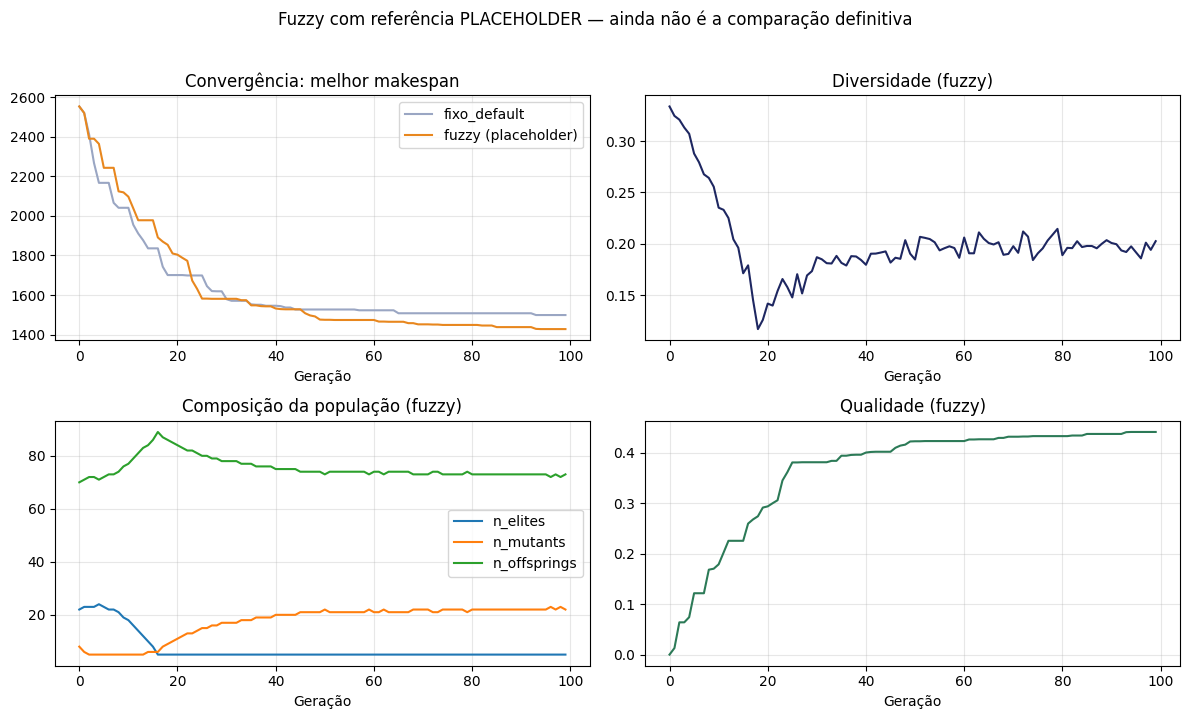


Nota: essa comparação usa referência placeholder (0.20/0.10) e parâmetros de
fábrica — serve só para confirmar que o mecanismo funciona. A comparação que
importa de verdade é a da seção 4.6, com Optuna + referência calibrada.


In [17]:
resultado_fuzzy_demo, historico_fuzzy_demo = run_brkga_fuzzy(
    engine, n_gen=N_GEN_CASO, seed=SEED_CASO,
    n_elites0=N_ELITES_DEFAULT, n_offsprings0=N_OFFSPRINGS_DEFAULT,
    n_mutants0=N_MUTANTS_DEFAULT, bias=BIAS_DEFAULT,
    frac_elites_min=FRAC_ELITES_MIN, frac_elites_max=FRAC_ELITES_MAX,
    frac_mutantes_min=FRAC_MUTANTES_MIN, frac_mutantes_max=FRAC_MUTANTES_MAX,
    frac_offsprings_min=FRAC_OFFSPRINGS_MIN,
)
print(f"[fuzzy, referência placeholder] melhor makespan: {resultado_fuzzy_demo['F']:.2f}")

gens_fd = [h["gen"] for h in historico_fuzzy_demo]
fig, axs = plt.subplots(2, 2, figsize=(12, 7))
axs[0,0].plot(gens, [h["best_makespan"] for h in historico_fixo], color="#9AA6C3", label="fixo_default")
axs[0,0].plot(gens_fd, [h["best_makespan"] for h in historico_fuzzy_demo], color="#E8871E", label="fuzzy (placeholder)")
axs[0,0].set_title("Convergência: melhor makespan"); axs[0,0].legend(); axs[0,0].grid(alpha=0.3)
axs[0,1].plot(gens_fd, [h["diversidade"] for h in historico_fuzzy_demo], color="#1E2761")
axs[0,1].set_title("Diversidade (fuzzy)"); axs[0,1].grid(alpha=0.3)
axs[1,0].plot(gens_fd, [h["n_elites"] for h in historico_fuzzy_demo], label="n_elites")
axs[1,0].plot(gens_fd, [h["n_mutants"] for h in historico_fuzzy_demo], label="n_mutants")
axs[1,0].plot(gens_fd, [h["n_offsprings"] for h in historico_fuzzy_demo], label="n_offsprings")
axs[1,0].set_title("Composição da população (fuzzy)"); axs[1,0].legend(); axs[1,0].grid(alpha=0.3)
axs[1,1].plot(gens_fd, [h["qualidade"] for h in historico_fuzzy_demo], color="#2C7A57")
axs[1,1].set_title("Qualidade (fuzzy)"); axs[1,1].grid(alpha=0.3)
for ax in axs.flat:
    ax.set_xlabel("Geração")
plt.suptitle("Fuzzy com referência PLACEHOLDER — ainda não é a comparação definitiva", y=1.02)
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/03_fuzzy_referencia_placeholder.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nNota: essa comparação usa referência placeholder (0.20/0.10) e parâmetros de")
print("fábrica — serve só para confirmar que o mecanismo funciona. A comparação que")
print("importa de verdade é a da seção 4.6, com Optuna + referência calibrada.")

### 4.5 Optuna: tuning do BRKGA fixo + calibração da referência

Duas etapas: (1) busca os melhores parâmetros para o BRKGA fixo; (2) roda essa
configuração em sementes novas e usa a trajetória média de diversidade/qualidade
como referência real dos controladores fuzzy (substitui o placeholder usado acima).

[I 2026-09-17 02:03:41,564] A new study created in memory with name: no-name-b166d08a-674d-4915-acb9-5617aeb35298
[I 2026-09-17 02:03:48,991] Trial 0 finished with value: 1546.0 and parameters: {'frac_elites': 0.24208472637456369, 'frac_mutantes': 0.30031627823034684, 'bias': 0.6712435192322397}. Best is trial 0 with value: 1546.0.
[I 2026-09-17 02:03:56,992] Trial 1 finished with value: 1446.6666666666667 and parameters: {'frac_elites': 0.24070911404891393, 'frac_mutantes': 0.19827917976861664, 'bias': 0.6906523508799953}. Best is trial 1 with value: 1446.6666666666667.
[I 2026-09-17 02:04:03,750] Trial 2 finished with value: 1536.3333333333333 and parameters: {'frac_elites': 0.20315552394194242, 'frac_mutantes': 0.3621205502737279, 'bias': 0.8336482422254632}. Best is trial 1 with value: 1446.6666666666667.
[I 2026-09-17 02:04:11,846] Trial 3 finished with value: 1557.6666666666667 and parameters: {'frac_elites': 0.18420453158902222, 'frac_mutantes': 0.3271037633289326, 'bias': 0.638

Melhor configuração encontrada pelo Optuna:
{'n_elites': 19, 'n_offsprings': 66, 'n_mutants': 15, 'bias': 0.7459762915681565}
Makespan médio (busca): 1302.67


/tmp/ipykernel_2631/2023066351.py:11: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  opt_viz.plot_optimization_history(study)


<Figure size 900x450 with 0 Axes>

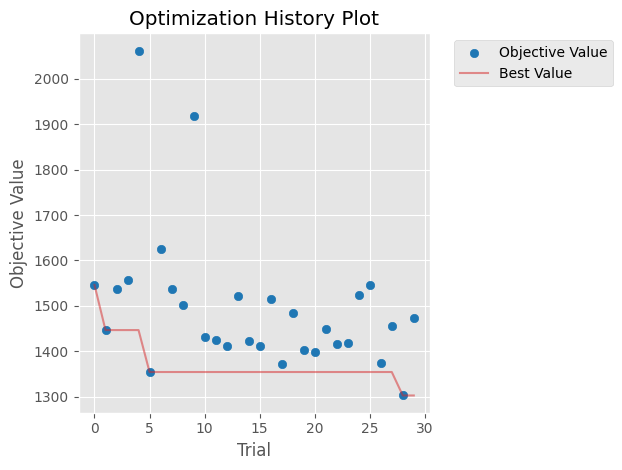

/tmp/ipykernel_2631/2023066351.py:17: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  opt_viz.plot_param_importances(study)


<Figure size 900x450 with 0 Axes>

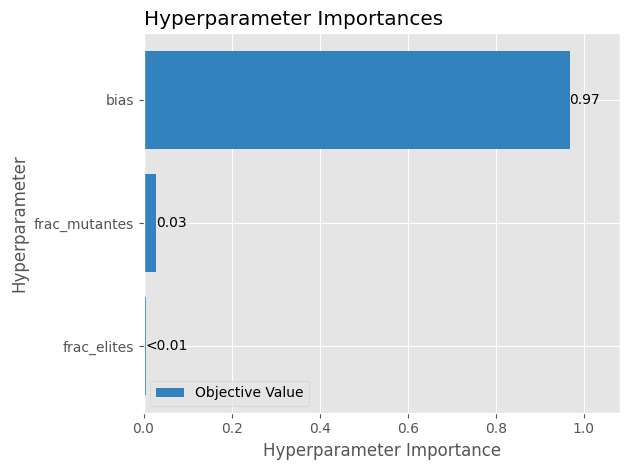

In [18]:
study, melhor_config = rodar_optuna(
    engine, pop_size=POP_SIZE, n_gen=N_GEN_CASO,
    seeds=tuple(range(1, N_SEEDS_BUSCA + 1)), n_trials=N_TRIALS_OPTUNA,
)
print("Melhor configuração encontrada pelo Optuna:")
print(melhor_config)
print(f"Makespan médio (busca): {study.best_value:.2f}")

import optuna.visualization.matplotlib as opt_viz
fig = plt.figure(figsize=(9, 4.5))
opt_viz.plot_optimization_history(study)
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/04_optuna_historico_busca.png", dpi=150)
plt.show()

fig = plt.figure(figsize=(9, 4.5))
opt_viz.plot_param_importances(study)
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/05_optuna_importancia_parametros.png", dpi=150)
plt.show()

Makespan médio (sementes de validação): 1454.00  +- 25.15


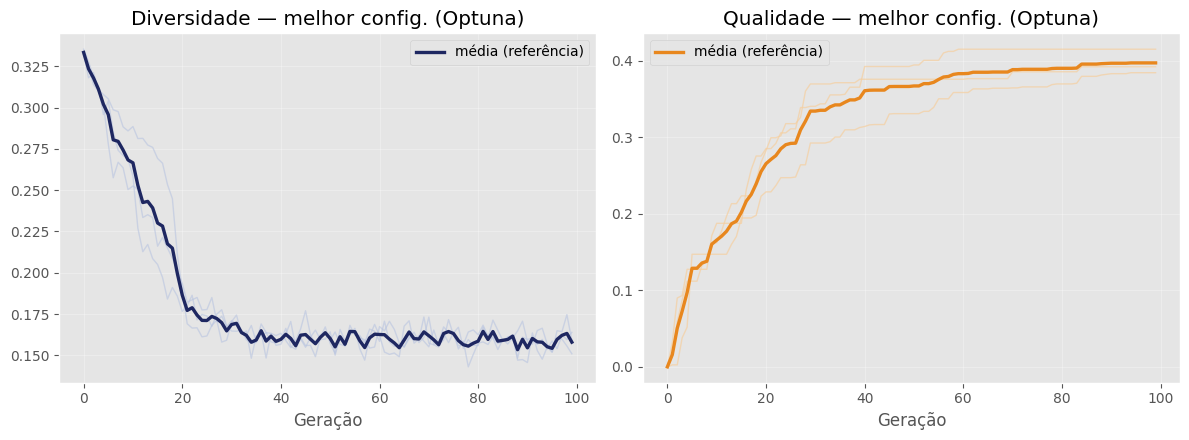

In [19]:
todas_metricas_val, trajetoria_diversidade, trajetoria_qualidade, resumo_val = analisar_melhor_configuracao(
    engine, melhor_config, n_gen=N_GEN_CASO, seeds=tuple(range(1000, 1000 + N_SEEDS_VALIDACAO)),
)
print(f"Makespan médio (sementes de validação): {resumo_val['makespan_medio']:.2f}  +- {resumo_val['makespan_desvio_padrao']:.2f}")

ref_diversidade_calibrada = construir_referencia_a_partir_da_trajetoria(trajetoria_diversidade)
ref_qualidade_calibrada = construir_referencia_a_partir_da_trajetoria(trajetoria_qualidade)

geracoes_val = list(range(len(trajetoria_diversidade)))
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
for ms in todas_metricas_val:
    axs[0].plot([m["diversidade"] for m in ms], color="#B8C4E0", alpha=0.6, linewidth=1)
axs[0].plot(geracoes_val, trajetoria_diversidade, color="#1E2761", linewidth=2.4, label="média (referência)")
axs[0].set_title("Diversidade — melhor config. (Optuna)"); axs[0].legend(); axs[0].grid(alpha=0.3)
for ms in todas_metricas_val:
    axs[1].plot([m["qualidade"] for m in ms], color="#F5CFA0", alpha=0.7, linewidth=1)
axs[1].plot(geracoes_val, trajetoria_qualidade, color="#E8871E", linewidth=2.4, label="média (referência)")
axs[1].set_title("Qualidade — melhor config. (Optuna)"); axs[1].legend(); axs[1].grid(alpha=0.3)
for ax in axs.flat:
    ax.set_xlabel("Geração")
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/06_trajetoria_calibrada.png", dpi=150)
plt.show()

### 4.6 Comparação definitiva: fixo_default × fixo_optuna × fuzzy (calibrado)

Esta é a comparação que importa — os 3 métodos, na mesma instância, mesmas
`N_SEEDS_COMPARACAO` sementes, mesmo número de gerações. O fuzzy usa a
configuração do Optuna como ponto de partida e a referência calibrada (não mais
o placeholder).

In [20]:
seeds_comparacao = tuple(range(SEED_COMPARACAO_INICIO, SEED_COMPARACAO_INICIO + N_SEEDS_COMPARACAO))

resultados_comparacao = []
historicos_fixo_default_comparacao = {}   # guardados para o gráfico de convergência por geração (4.6b)
historicos_fixo_optuna_comparacao = {}
historicos_fuzzy_comparacao = {}          # e para o diagnóstico da seção 5, sem precisar rodar de novo

for seed in seeds_comparacao:
    r_fd, hist_fd = run_brkga_fixo(
        engine, n_gen=N_GEN_CASO, seed=seed,
        n_elites=N_ELITES_DEFAULT, n_offsprings=N_OFFSPRINGS_DEFAULT,
        n_mutants=N_MUTANTS_DEFAULT, bias=BIAS_DEFAULT,
    )
    r_fo, hist_fo = run_brkga_fixo(
        engine, n_gen=N_GEN_CASO, seed=seed,
        n_elites=melhor_config["n_elites"], n_offsprings=melhor_config["n_offsprings"],
        n_mutants=melhor_config["n_mutants"], bias=melhor_config["bias"],
    )
    m_fz, hist_fz = run_brkga_fuzzy(
        engine, n_gen=N_GEN_CASO, seed=seed,
        n_elites0=melhor_config["n_elites"], n_offsprings0=melhor_config["n_offsprings"],
        n_mutants0=melhor_config["n_mutants"], bias=melhor_config["bias"],
        frac_elites_min=FRAC_ELITES_MIN, frac_elites_max=FRAC_ELITES_MAX,
        frac_mutantes_min=FRAC_MUTANTES_MIN, frac_mutantes_max=FRAC_MUTANTES_MAX,
        frac_offsprings_min=FRAC_OFFSPRINGS_MIN,
        ref_diversidade=ref_diversidade_calibrada, ref_qualidade=ref_qualidade_calibrada,
    )
    resultados_comparacao.append({
        "seed": seed, "fixo_default": r_fd.F[0], "fixo_optuna": r_fo.F[0], "fuzzy": m_fz["F"],
    })
    historicos_fixo_default_comparacao[seed] = hist_fd
    historicos_fixo_optuna_comparacao[seed] = hist_fo
    historicos_fuzzy_comparacao[seed] = hist_fz

import pandas as pd
df_comparacao = pd.DataFrame(resultados_comparacao)
print(df_comparacao.to_string(index=False))
print()
print("=== Resumo (Cmax por método) ===")
resumo_comparacao = df_comparacao[["fixo_default", "fixo_optuna", "fuzzy"]].agg(["mean", "std", "min", "max"]).round(2)
print(resumo_comparacao)
df_comparacao.to_csv(f"{PASTA_SAIDA}/comparacao_final_{N_SEEDS_COMPARACAO}sementes.csv", index=False)

 seed  fixo_default  fixo_optuna  fuzzy
  100        1591.0       1442.0 1330.0
  101        1387.0       1491.0 1452.0
  102        1324.0       1405.0 1284.0
  103        1425.0       1409.0 1575.0
  104        1499.0       1531.0 1489.0
  105        1419.0       1498.0 1662.0
  106        1446.0       1412.0 1576.0
  107        1462.0       1546.0 1485.0
  108        1461.0       1414.0 1542.0
  109        1428.0       1357.0 1419.0

=== Resumo (Cmax por método) ===
      fixo_default  fixo_optuna    fuzzy
mean       1444.20      1450.50  1481.40
std          70.03        62.29   115.81
min        1324.00      1357.00  1284.00
max        1591.00      1546.00  1662.00


/tmp/ipykernel_2631/2949335006.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axs[1].boxplot([df_comparacao[m] for m in metodos_comp], labels=nomes_comp, patch_artist=True)


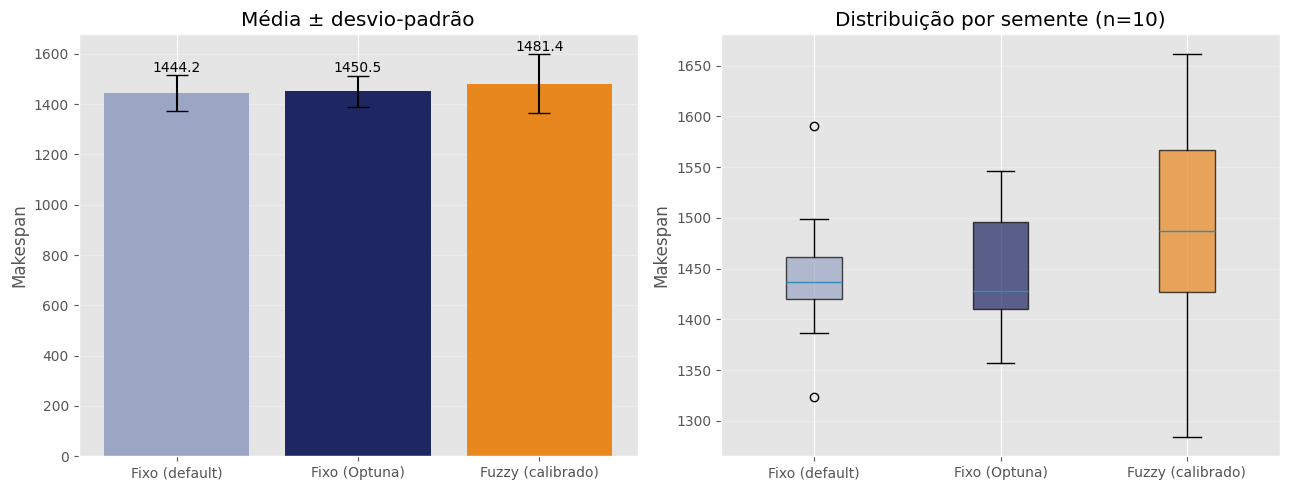

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

metodos_comp = ["fixo_default", "fixo_optuna", "fuzzy"]
nomes_comp = ["Fixo (default)", "Fixo (Optuna)", "Fuzzy (calibrado)"]
cores_comp = ["#9AA6C3", "#1E2761", "#E8871E"]

medias_comp = [df_comparacao[m].mean() for m in metodos_comp]
desvios_comp = [df_comparacao[m].std() for m in metodos_comp]
axs[0].bar(nomes_comp, medias_comp, yerr=desvios_comp, capsize=8, color=cores_comp)
for i, (m, d) in enumerate(zip(medias_comp, desvios_comp)):
    axs[0].text(i, m + d + max(medias_comp)*0.01, f"{m:.1f}", ha="center", fontsize=10)
axs[0].set_ylabel("Makespan"); axs[0].set_title("Média ± desvio-padrão"); axs[0].grid(alpha=0.3, axis="y")

box = axs[1].boxplot([df_comparacao[m] for m in metodos_comp], labels=nomes_comp, patch_artist=True)
for patch, cor in zip(box["boxes"], cores_comp):
    patch.set_facecolor(cor); patch.set_alpha(0.7)
axs[1].set_ylabel("Makespan"); axs[1].set_title(f"Distribuição por semente (n={N_SEEDS_COMPARACAO})"); axs[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/07_comparacao_final_3metodos.png", dpi=150)
plt.show()

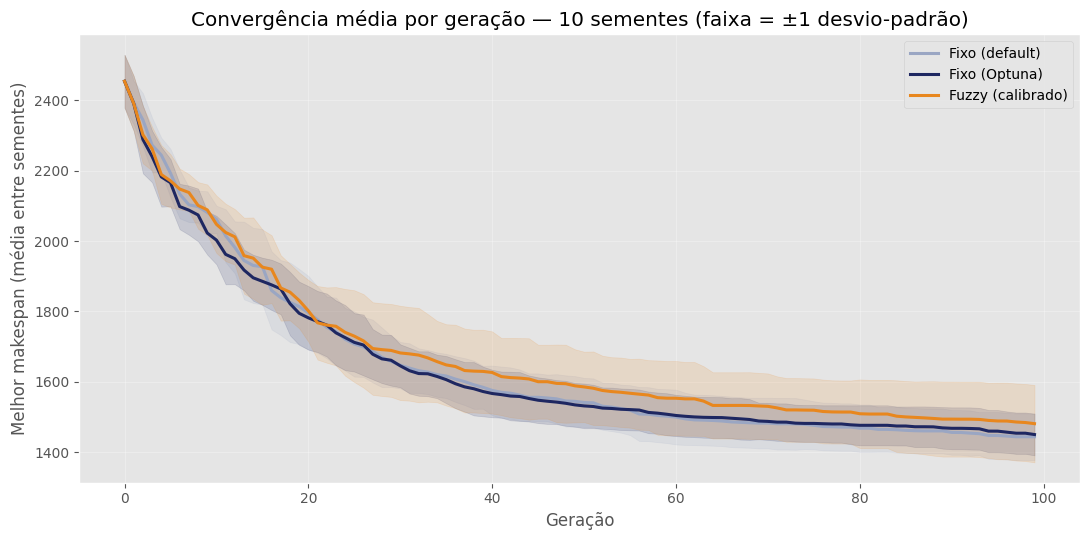

In [22]:
import numpy as np

def _matriz_makespan_por_geracao(historicos_dict):
    return np.array([[h["best_makespan"] for h in hist] for hist in historicos_dict.values()])

matriz_fd = _matriz_makespan_por_geracao(historicos_fixo_default_comparacao)
matriz_fo = _matriz_makespan_por_geracao(historicos_fixo_optuna_comparacao)
matriz_fz = _matriz_makespan_por_geracao(historicos_fuzzy_comparacao)
gens_plot = list(range(matriz_fd.shape[1]))

fig, ax = plt.subplots(figsize=(11, 5.5))
for matriz, nome, cor in zip([matriz_fd, matriz_fo, matriz_fz], nomes_comp, cores_comp):
    media = matriz.mean(axis=0)
    desvio = matriz.std(axis=0)
    ax.plot(gens_plot, media, color=cor, linewidth=2.2, label=nome)
    ax.fill_between(gens_plot, media - desvio, media + desvio, color=cor, alpha=0.15)

ax.set_xlabel("Geração")
ax.set_ylabel("Melhor makespan (média entre sementes)")
ax.set_title(f"Convergência média por geração — {N_SEEDS_COMPARACAO} sementes (faixa = ±1 desvio-padrão)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/07b_convergencia_por_geracao.png", dpi=150)
plt.show()

In [23]:
for seed, hist in historicos_fuzzy_comparacao.items():
    frac_teto = sum(1 for h in hist if h["n_elites"] >= 39) / len(hist)
    print(seed, hist[-1]["best_makespan"], frac_teto)

100 1330.0 0.0
101 1452.0 0.73
102 1284.0 0.0
103 1575.0 0.03
104 1489.0 0.8
105 1662.0 0.45
106 1576.0 0.0
107 1485.0 0.21
108 1542.0 0.69
109 1419.0 0.0


## 5. Diagnóstico de uma semente específica (opcional)

Só roda se `DIAGNOSTICO_SEED` (na configuração) for diferente de `None`. Útil
para investigar uma execução que chamou atenção (por exemplo, um makespan bem
pior que as outras sementes) — mostra a evolução completa dessa execução e
compara com o padrão das outras sementes já rodadas na seção 4.6.

In [24]:
if DIAGNOSTICO_SEED is None:
    print("DIAGNOSTICO_SEED = None — seção pulada. Defina um número de seed na configuração para ativar.")
else:
    if DIAGNOSTICO_SEED in historicos_fuzzy_comparacao:
        hist_diag = historicos_fuzzy_comparacao[DIAGNOSTICO_SEED]
        makespan_diag = hist_diag[-1]["best_makespan"]
        print(f"Reaproveitando execução já feita na seção 4.6 para a seed {DIAGNOSTICO_SEED}.")
    else:
        print(f"Seed {DIAGNOSTICO_SEED} não estava entre as sementes de comparação — rodando agora.")
        melhor_diag, hist_diag = run_brkga_fuzzy(
            engine, n_gen=N_GEN_CASO, seed=DIAGNOSTICO_SEED,
            n_elites0=melhor_config["n_elites"], n_offsprings0=melhor_config["n_offsprings"],
            n_mutants0=melhor_config["n_mutants"], bias=melhor_config["bias"],
            frac_elites_min=FRAC_ELITES_MIN, frac_elites_max=FRAC_ELITES_MAX,
            frac_mutantes_min=FRAC_MUTANTES_MIN, frac_mutantes_max=FRAC_MUTANTES_MAX,
            frac_offsprings_min=FRAC_OFFSPRINGS_MIN,
            ref_diversidade=ref_diversidade_calibrada, ref_qualidade=ref_qualidade_calibrada,
        )
        makespan_diag = melhor_diag["F"]

    print(f"Makespan seed {DIAGNOSTICO_SEED}: {makespan_diag:.2f}")

    gens_diag = [h["gen"] for h in hist_diag]
    fig, axs = plt.subplots(2, 2, figsize=(12, 7))
    axs[0,0].plot(gens_diag, [h["best_makespan"] for h in hist_diag], color="#8C2F39")
    axs[0,0].set_title(f"Makespan (seed {DIAGNOSTICO_SEED})"); axs[0,0].grid(alpha=0.3)
    axs[0,1].plot(gens_diag, [h["diversidade"] for h in hist_diag], color="#1E2761")
    axs[0,1].set_title("Diversidade"); axs[0,1].grid(alpha=0.3)
    axs[1,0].plot(gens_diag, [h["n_elites"] for h in hist_diag], label="n_elites")
    axs[1,0].plot(gens_diag, [h["n_mutants"] for h in hist_diag], label="n_mutants")
    axs[1,0].plot(gens_diag, [h["n_offsprings"] for h in hist_diag], label="n_offsprings")
    axs[1,0].set_title("Composição da população"); axs[1,0].legend(); axs[1,0].grid(alpha=0.3)
    axs[1,1].plot(gens_diag, [h["qualidade"] for h in hist_diag], color="#2C7A57")
    axs[1,1].set_title("Qualidade"); axs[1,1].grid(alpha=0.3)
    for ax in axs.flat:
        ax.set_xlabel("Geração")
    plt.suptitle(f"Diagnóstico — seed {DIAGNOSTICO_SEED}", y=1.02)
    plt.tight_layout()
    plt.savefig(f"{PASTA_SAIDA}/08_diagnostico_seed_{DIAGNOSTICO_SEED}.png", dpi=150, bbox_inches="tight")
    plt.show()

DIAGNOSTICO_SEED = None — seção pulada. Defina um número de seed na configuração para ativar.


In [25]:
# Correlação entre "ficar preso no teto de elites" e o makespan final,
# usando as sementes já rodadas na seção 4.6 (sem rodar nada de novo).
if DIAGNOSTICO_SEED is not None and len(historicos_fuzzy_comparacao) >= 5:
    teto_elites = round(FRAC_ELITES_MAX * POP_SIZE)
    linhas_diag = []
    for seed, hist in historicos_fuzzy_comparacao.items():
        frac_no_teto = sum(1 for h in hist if h["n_elites"] >= teto_elites - 1) / len(hist)
        linhas_diag.append({
            "seed": seed,
            "makespan": hist[-1]["best_makespan"],
            "qualidade_final": hist[-1]["qualidade"],
            "frac_gens_no_teto_elites": frac_no_teto,
        })
    df_diag = pd.DataFrame(linhas_diag).sort_values("makespan")
    print(df_diag.to_string(index=False))

    corr_pearson = df_diag["makespan"].corr(df_diag["frac_gens_no_teto_elites"])
    print(f"\nCorrelação (Pearson) makespan x fração de gerações no teto: {corr_pearson:.3f}")

    from scipy.stats import spearmanr
    if df_diag["frac_gens_no_teto_elites"].nunique() > 1:
        r_s, p_s = spearmanr(df_diag["frac_gens_no_teto_elites"], df_diag["makespan"])
        print(f"Correlação (Spearman): r={r_s:.3f}  p-valor={p_s:.4f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(df_diag["frac_gens_no_teto_elites"], df_diag["makespan"], s=90, color="#E8871E", edgecolor="white", linewidth=1)
    ax.set_xlabel(f"Fração de gerações com n_elites no teto ({teto_elites})")
    ax.set_ylabel("Makespan final")
    ax.set_title("Saturação do controlador de elites x makespan")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PASTA_SAIDA}/09_correlacao_teto_elites.png", dpi=150)
    plt.show()
elif DIAGNOSTICO_SEED is not None:
    print(f"Poucas sementes em historicos_fuzzy_comparacao ({len(historicos_fuzzy_comparacao)}) "
          f"para uma correlação significativa — aumente N_SEEDS_COMPARACAO na configuração.")

In [26]:
print(df_diag[["seed", "makespan", "frac_gens_no_teto_elites"]])
print("Pearson:", df_diag["makespan"].corr(df_diag["frac_gens_no_teto_elites"]))

NameError: name 'df_diag' is not defined

In [27]:
print(NOME_INSTANCIA)
print(engine.n_jobs, engine.n_machines)
print(N_GEN_CASO)
print(POP_SIZE, N_ELITES_DEFAULT, N_OFFSPRINGS_DEFAULT, N_MUTANTS_DEFAULT)

Small/I_2_16_5_1.txt
16 5
100
100 20 70 10


## 6. Experimentos com várias instâncias

Só roda se `RODAR_EXPERIMENTOS_MULTINSTANCIA = True` na configuração — essa
seção pode demorar bastante (cada instância repete todo o processo de tuning +
calibração + comparação). As instâncias são escolhidas automaticamente do zip,
espalhadas entre os diferentes tamanhos (não pega só as primeiras do arquivo).

In [28]:
def selecionar_amostra_instancias(caminho_zip, n_total, seed=0):
    """Escolhe uma amostra de instâncias espalhada entre os diferentes tamanhos
    (jobs, máquinas), em vez de pegar só as primeiras do zip."""
    import random
    import re
    from collections import defaultdict

    todas = listar_instancias_zip(caminho_zip)
    grupos = defaultdict(list)
    padrao = re.compile(r"I_(\d+)_(\d+)_(\d+)_(\d+)")
    for nome in todas:
        m = padrao.search(nome)
        chave = (int(m.group(2)), int(m.group(3))) if m else ("desconhecido",)
        grupos[chave].append(nome)

    rng = random.Random(seed)
    n_grupos = len(grupos)
    base_por_grupo = max(1, n_total // n_grupos)

    selecionadas = []
    for lista in grupos.values():
        lista_embaralhada = lista[:]
        rng.shuffle(lista_embaralhada)
        selecionadas.extend(lista_embaralhada[:base_por_grupo])

    faltam = n_total - len(selecionadas)
    if faltam > 0:
        restantes = [n for n in todas if n not in selecionadas]
        rng.shuffle(restantes)
        selecionadas.extend(restantes[:faltam])

    return sorted(selecionadas[:n_total])

In [29]:
if not RODAR_EXPERIMENTOS_MULTINSTANCIA:
    print("RODAR_EXPERIMENTOS_MULTINSTANCIA = False — seção pulada.")
    print("Mude para True na configuração quando quiser rodar (pode demorar).")
else:
    instancias_experimento = selecionar_amostra_instancias(
        CAMINHO_ZIP, N_INSTANCIAS_EXPERIMENTO, seed=SEED_SELECAO_INSTANCIAS
    )
    print(f"{len(instancias_experimento)} instâncias selecionadas:")
    for nome in instancias_experimento:
        print(f"  {nome}")

RODAR_EXPERIMENTOS_MULTINSTANCIA = False — seção pulada.
Mude para True na configuração quando quiser rodar (pode demorar).


In [30]:
import time
import csv

CAMPOS_CSV_EXP = [
    "instancia", "n_jobs", "n_machines", "metodo", "seed", "n_gen",
    "best_makespan", "diversidade_media", "qualidade_media",
    "erro_diversidade_medio_abs", "erro_qualidade_medio_abs",
    "estabilidade_n_elites_std", "estabilidade_n_mutants_std",
]

def _registrar_execucao_exp(historico, ref_div, ref_qual, params_pop=None):
    metricas = computar_metricas(historico, ref_diversidade=ref_div, ref_qualidade=ref_qual)
    diversidades = [m["diversidade"] for m in metricas]
    qualidades = [m["qualidade"] for m in metricas]
    erros_div = [abs(m["erro_diversidade"]) for m in metricas]
    erros_qual = [abs(m["erro_qualidade"]) for m in metricas]
    if params_pop is not None:
        estab_e = float(np.std([p["n_elites"] for p in params_pop]))
        estab_m = float(np.std([p["n_mutants"] for p in params_pop]))
    else:
        estab_e, estab_m = 0.0, 0.0
    return {
        "best_makespan": historico[-1]["best_makespan"],
        "diversidade_media": float(np.mean(diversidades)),
        "qualidade_media": float(np.mean(qualidades)),
        "erro_diversidade_medio_abs": float(np.mean(erros_div)),
        "erro_qualidade_medio_abs": float(np.mean(erros_qual)),
        "estabilidade_n_elites_std": estab_e,
        "estabilidade_n_mutants_std": estab_m,
    }

if RODAR_EXPERIMENTOS_MULTINSTANCIA:
    import numpy as np
    caminho_csv_exp = f"{PASTA_SAIDA}/resultados_experimentos.csv"
    t0_exp = time.time()

    with open(caminho_csv_exp, "w", newline="") as f_csv:
        writer = csv.DictWriter(f_csv, fieldnames=CAMPOS_CSV_EXP)
        writer.writeheader()

        for nome_inst in instancias_experimento:
            engine_exp = montar_engine_de_zip(CAMINHO_ZIP, nome_inst)
            print(f"\n=== {nome_inst} (n_jobs={engine_exp.n_jobs}, n_machines={engine_exp.n_machines}) ===")

            seeds_busca_exp = tuple(range(1, N_SEEDS_OPTUNA_EXPERIMENTO + 1))
            seeds_valid_exp = tuple(range(1000, 1000 + N_SEEDS_OPTUNA_EXPERIMENTO))
            seeds_exp_exp = tuple(range(2000, 2000 + N_SEEDS_EXPERIMENTO))

            _, melhor_config_exp = rodar_optuna(
                engine_exp, pop_size=POP_SIZE, n_gen=N_GEN_EXPERIMENTO,
                seeds=seeds_busca_exp, n_trials=N_TRIALS_OPTUNA_EXPERIMENTO,
            )
            _, traj_div_exp, traj_qual_exp, _ = analisar_melhor_configuracao(
                engine_exp, melhor_config_exp, n_gen=N_GEN_EXPERIMENTO, seeds=seeds_valid_exp,
            )
            ref_div_exp = construir_referencia_a_partir_da_trajetoria(traj_div_exp)
            ref_qual_exp = construir_referencia_a_partir_da_trajetoria(traj_qual_exp)

            for seed in seeds_exp_exp:
                r_fd, h_fd = run_brkga_fixo(
                    engine_exp, n_gen=N_GEN_EXPERIMENTO, seed=seed,
                    n_elites=N_ELITES_DEFAULT, n_offsprings=N_OFFSPRINGS_DEFAULT,
                    n_mutants=N_MUTANTS_DEFAULT, bias=BIAS_DEFAULT,
                )
                linha = {"instancia": nome_inst, "n_jobs": engine_exp.n_jobs, "n_machines": engine_exp.n_machines,
                         "metodo": "fixo_default", "seed": seed, "n_gen": N_GEN_EXPERIMENTO}
                linha.update(_registrar_execucao_exp(h_fd, ref_div_exp, ref_qual_exp))
                writer.writerow(linha)

                r_fo, h_fo = run_brkga_fixo(
                    engine_exp, n_gen=N_GEN_EXPERIMENTO, seed=seed,
                    n_elites=melhor_config_exp["n_elites"], n_offsprings=melhor_config_exp["n_offsprings"],
                    n_mutants=melhor_config_exp["n_mutants"], bias=melhor_config_exp["bias"],
                )
                linha = {"instancia": nome_inst, "n_jobs": engine_exp.n_jobs, "n_machines": engine_exp.n_machines,
                         "metodo": "fixo_optuna", "seed": seed, "n_gen": N_GEN_EXPERIMENTO}
                linha.update(_registrar_execucao_exp(h_fo, ref_div_exp, ref_qual_exp))
                writer.writerow(linha)

                m_fz, h_fz = run_brkga_fuzzy(
                    engine_exp, n_gen=N_GEN_EXPERIMENTO, seed=seed,
                    n_elites0=melhor_config_exp["n_elites"], n_offsprings0=melhor_config_exp["n_offsprings"],
                    n_mutants0=melhor_config_exp["n_mutants"], bias=melhor_config_exp["bias"],
                    frac_elites_min=FRAC_ELITES_MIN, frac_elites_max=FRAC_ELITES_MAX,
                    frac_mutantes_min=FRAC_MUTANTES_MIN, frac_mutantes_max=FRAC_MUTANTES_MAX,
                    frac_offsprings_min=FRAC_OFFSPRINGS_MIN,
                    ref_diversidade=ref_div_exp, ref_qualidade=ref_qual_exp,
                )
                linha = {"instancia": nome_inst, "n_jobs": engine_exp.n_jobs, "n_machines": engine_exp.n_machines,
                         "metodo": "fuzzy", "seed": seed, "n_gen": N_GEN_EXPERIMENTO}
                linha.update(_registrar_execucao_exp(h_fz, ref_div_exp, ref_qual_exp, params_pop=h_fz))
                writer.writerow(linha)

                f_csv.flush()

            print(f"  fixo_default={r_fd.F[0]:.1f}  fixo_optuna={r_fo.F[0]:.1f}  fuzzy={m_fz['F']:.1f}  (última seed)")

    print(f"\nTempo total: {time.time()-t0_exp:.1f}s")
    print(f"Resultados salvos em: {caminho_csv_exp}")

### 6.1 Análise agregada dos experimentos

In [31]:
if RODAR_EXPERIMENTOS_MULTINSTANCIA:
    df_exp = pd.read_csv(caminho_csv_exp)

    def bucket(n):
        if n <= 6: return "Pequena (\u22646 jobs)"
        elif n <= 12: return "M\u00e9dia (8-12 jobs)"
        else: return "Grande (\u226514 jobs)"
    df_exp["tamanho"] = df_exp["n_jobs"].apply(bucket)

    NOMES_M = {"fixo_default": "Fixo (default)", "fixo_optuna": "Fixo (Optuna)", "fuzzy": "Fuzzy"}
    CORES_M = {"fixo_default": "#9AA6C3", "fixo_optuna": "#1E2761", "fuzzy": "#E8871E"}
    METODOS_M = ["fixo_default", "fixo_optuna", "fuzzy"]

    medias_exp = df_exp.groupby(["instancia", "metodo"])["best_makespan"].mean().unstack()
    relativo_exp = medias_exp.div(medias_exp["fixo_default"], axis=0) * 100
    relativo_exp["tamanho"] = df_exp.drop_duplicates("instancia").set_index("instancia")["tamanho"]
    ordem_exp = [t for t in ["Pequena (\u22646 jobs)", "M\u00e9dia (8-12 jobs)", "Grande (\u226514 jobs)"] if t in relativo_exp["tamanho"].unique()]
    agrupado_exp = relativo_exp.groupby("tamanho")[METODOS_M].mean().reindex(ordem_exp)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(agrupado_exp)); w = 0.25
    for i, met in enumerate(METODOS_M):
        ax.bar(x + (i-1)*w, agrupado_exp[met], w, label=NOMES_M[met], color=CORES_M[met])
    ax.axhline(100, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(x); ax.set_xticklabels(agrupado_exp.index)
    ax.set_ylabel("Makespan relativo ao fixo_default (%)")
    ax.set_title("Makespan médio por método e tamanho de instância")
    ax.legend(); ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"{PASTA_SAIDA}/10_makespan_por_tamanho.png", dpi=150)
    plt.show()

    resumo_exp = df_exp.groupby(["tamanho", "metodo"]).agg(
        makespan_medio=("best_makespan", "mean"),
        makespan_std=("best_makespan", "std"),
    ).round(1)
    print(resumo_exp)
    resumo_exp.to_csv(f"{PASTA_SAIDA}/resumo_experimentos.csv")
else:
    print("RODAR_EXPERIMENTOS_MULTINSTANCIA = False — nada para analisar ainda.")

RODAR_EXPERIMENTOS_MULTINSTANCIA = False — nada para analisar ainda.


## Resumo dos arquivos gerados

Todos salvos em `PASTA_SAIDA` (definida na configuração):

- `01_convergencia_fixo_default.png`
- `02_metricas_referencia_placeholder.png`
- `03_fuzzy_referencia_placeholder.png`
- `04_optuna_historico_busca.png`, `05_optuna_importancia_parametros.png`
- `06_trajetoria_calibrada.png`
- `07_comparacao_final_3metodos.png` + `comparacao_final_<N>sementes.csv`
- `08_diagnostico_seed_<N>.png`, `09_correlacao_teto_elites.png` (se `DIAGNOSTICO_SEED` estiver definido)
- `10_makespan_por_tamanho.png` + `resultados_experimentos.csv` + `resumo_experimentos.csv` (se `RODAR_EXPERIMENTOS_MULTINSTANCIA = True`)


In [32]:
import csv, time
import numpy as np
import pandas as pd

# Reaproveita o que já está calculado na sessão — não roda o Optuna de novo
print("Configuração usada em todas as 420 instâncias:")
print(melhor_config)

todas_instancias = listar_instancias_zip(CAMINHO_ZIP)
print(f"{len(todas_instancias)} instâncias encontradas")

caminho_csv_420 = f"{PASTA_SAIDA}/tabela_420_instancias.csv"
campos_420 = ["instancia", "n_jobs", "n_machines", "media_optuna", "media_fuzzy", "menor_makespan", "metodo_do_menor"]

ja_processadas = set()
if os.path.exists(caminho_csv_420):
    ja_processadas = set(pd.read_csv(caminho_csv_420)["instancia"])
    print(f"Retomando: {len(ja_processadas)} instâncias já feitas antes.")

novo_arquivo = not os.path.exists(caminho_csv_420)
with open(caminho_csv_420, "a", newline="") as f_csv:
    writer = csv.DictWriter(f_csv, fieldnames=campos_420)
    if novo_arquivo:
        writer.writeheader()

    t0 = time.time()
    for i, nome_inst in enumerate(todas_instancias):
        if nome_inst in ja_processadas:
            continue

        engine_i = montar_engine_de_zip(CAMINHO_ZIP, nome_inst)

        makespans_optuna, makespans_fuzzy = [], []
        for seed in range(2000, 2010):
            r_o, _ = run_brkga_fixo(engine_i, n_gen=N_GEN_EXPERIMENTO, seed=seed,
                                     n_elites=melhor_config["n_elites"], n_offsprings=melhor_config["n_offsprings"],
                                     n_mutants=melhor_config["n_mutants"], bias=melhor_config["bias"])
            makespans_optuna.append(r_o.F[0])

            m_f, _ = run_brkga_fuzzy(engine_i, n_gen=N_GEN_EXPERIMENTO, seed=seed,
                                      n_elites0=melhor_config["n_elites"], n_offsprings0=melhor_config["n_offsprings"],
                                      n_mutants0=melhor_config["n_mutants"], bias=melhor_config["bias"],
                                      ref_diversidade=ref_diversidade_calibrada, ref_qualidade=ref_qualidade_calibrada)
            makespans_fuzzy.append(m_f["F"])

        todos = makespans_optuna + makespans_fuzzy
        writer.writerow({
            "instancia": nome_inst, "n_jobs": engine_i.n_jobs, "n_machines": engine_i.n_machines,
            "media_optuna": round(np.mean(makespans_optuna), 2),
            "media_fuzzy": round(np.mean(makespans_fuzzy), 2),
            "menor_makespan": min(todos),
            "metodo_do_menor": "optuna" if min(todos) in makespans_optuna else "fuzzy",
        })
        f_csv.flush()

        if (i + 1) % 10 == 0:
            decorrido = time.time() - t0
            restante = (len(todas_instancias) - i - 1) * (decorrido / (i + 1))
            print(f"[{i+1}/{len(todas_instancias)}] {nome_inst} — tempo restante estimado: {restante/60:.0f} min")

print(f"\nConcluído. Resultados em: {caminho_csv_420}")

Configuração usada em todas as 420 instâncias:
{'n_elites': 19, 'n_offsprings': 66, 'n_mutants': 15, 'bias': 0.7459762915681565}
420 instâncias encontradas


KeyboardInterrupt: 

Total de instâncias: 6
                      métrica  valor
      Makespan médio (Optuna) 733.53
       Makespan médio (Fuzzy) 738.05
Instâncias onde Optuna venceu   4.00
 Instâncias onde Fuzzy venceu   2.00

Diferença média (fuzzy vs optuna): -0.36%
Fuzzy foi melhor em 3 de 6 instâncias (50.0%)


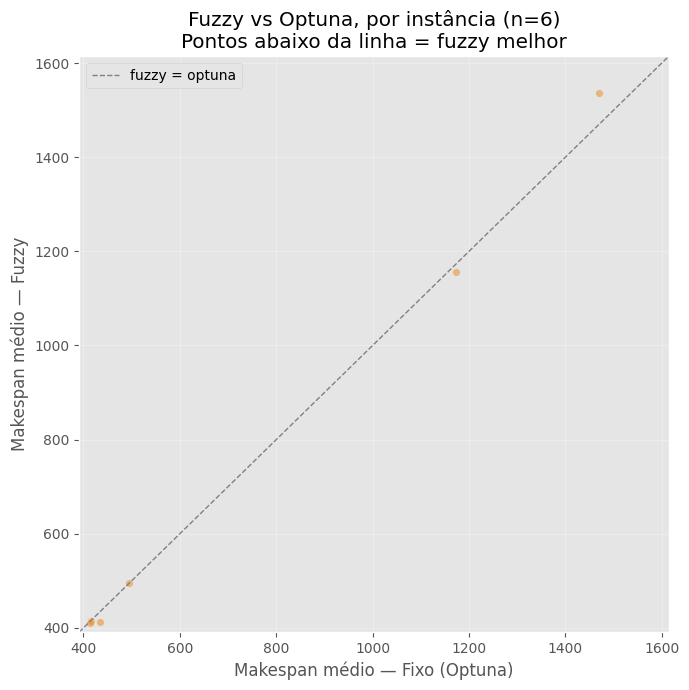

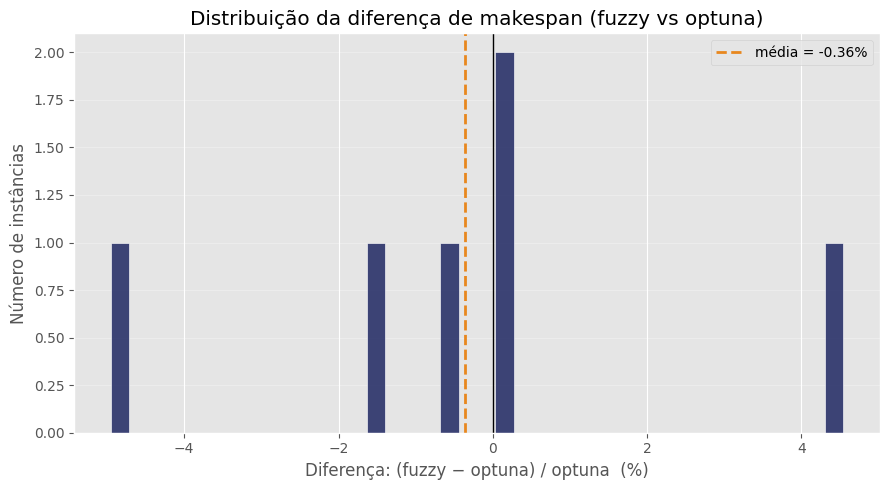

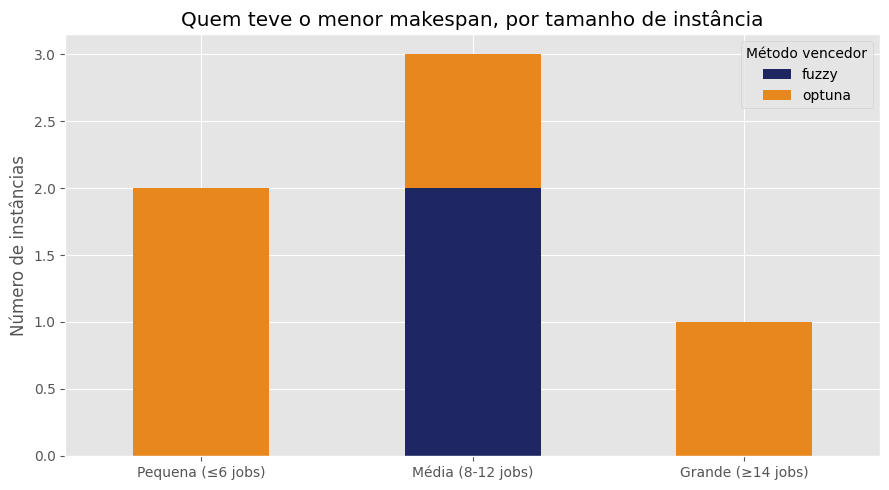


=== Resumo por tamanho ===
                   n_instancias  media_optuna  media_fuzzy  dif_media_pct
tamanho                                                                  
Pequena (≤6 jobs)             2        414.10       413.25          -0.21
Média (8-12 jobs)             3        700.83       688.17          -2.10
Grande (≥14 jobs)             1       1470.50      1537.30           4.54


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NAVY, AMBER, GRAY = "#1E2761", "#E8871E", "#9AA6C3"

df = pd.read_csv(f"{PASTA_SAIDA}/tabela_420_instancias.csv")   # ajusta o caminho se precisar
print(f"Total de instâncias: {len(df)}")

# === 1. Tabela resumo geral ===
resumo_geral = pd.DataFrame({
    "métrica": ["Makespan médio (Optuna)", "Makespan médio (Fuzzy)", "Instâncias onde Optuna venceu", "Instâncias onde Fuzzy venceu"],
    "valor": [
        round(df["media_optuna"].mean(), 2),
        round(df["media_fuzzy"].mean(), 2),
        (df["metodo_do_menor"] == "optuna").sum(),
        (df["metodo_do_menor"] == "fuzzy").sum(),
    ]
})
print(resumo_geral.to_string(index=False))

# === 2. Diferença percentual por instância ===
df["dif_pct"] = (df["media_fuzzy"] - df["media_optuna"]) / df["media_optuna"] * 100
print(f"\nDiferença média (fuzzy vs optuna): {df['dif_pct'].mean():.2f}%")
print(f"Fuzzy foi melhor em {(df['dif_pct'] < 0).sum()} de {len(df)} instâncias ({(df['dif_pct'] < 0).mean()*100:.1f}%)")

# === Gráfico 1: dispersão optuna x fuzzy ===
fig, ax = plt.subplots(figsize=(7, 7))
lim = [df[["media_optuna", "media_fuzzy"]].min().min() * 0.95, df[["media_optuna", "media_fuzzy"]].max().max() * 1.05]
ax.plot(lim, lim, "--", color="gray", linewidth=1, label="fuzzy = optuna")
ax.scatter(df["media_optuna"], df["media_fuzzy"], alpha=0.5, color=AMBER, edgecolor="white", linewidth=0.3, s=30)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Makespan médio — Fixo (Optuna)")
ax.set_ylabel("Makespan médio — Fuzzy")
ax.set_title(f"Fuzzy vs Optuna, por instância (n={len(df)})\nPontos abaixo da linha = fuzzy melhor")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/grafico1_dispersao_420.png", dpi=150)
plt.show()

# === Gráfico 2: histograma da diferença percentual ===
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["dif_pct"], bins=40, color=NAVY, edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(df["dif_pct"].mean(), color=AMBER, linewidth=2, linestyle="--", label=f"média = {df['dif_pct'].mean():.2f}%")
ax.set_xlabel("Diferença: (fuzzy − optuna) / optuna  (%)")
ax.set_ylabel("Número de instâncias")
ax.set_title("Distribuição da diferença de makespan (fuzzy vs optuna)")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/grafico2_histograma_420.png", dpi=150)
plt.show()

# === Gráfico 3: quem venceu, por tamanho de instância ===
def bucket(n):
    if n <= 6: return "Pequena (\u22646 jobs)"
    elif n <= 12: return "Média (8-12 jobs)"
    else: return "Grande (\u226514 jobs)"
df["tamanho"] = df["n_jobs"].apply(bucket)

vitorias = df.groupby(["tamanho", "metodo_do_menor"]).size().unstack(fill_value=0)
ordem = [t for t in ["Pequena (\u22646 jobs)", "Média (8-12 jobs)", "Grande (\u226514 jobs)"] if t in vitorias.index]
vitorias = vitorias.reindex(ordem)

fig, ax = plt.subplots(figsize=(9, 5))
vitorias.plot(kind="bar", stacked=True, color=[NAVY, AMBER], ax=ax)
ax.set_ylabel("Número de instâncias"); ax.set_xlabel("")
ax.set_title("Quem teve o menor makespan, por tamanho de instância")
ax.legend(title="Método vencedor")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{PASTA_SAIDA}/grafico3_vitorias_por_tamanho.png", dpi=150)
plt.show()

# === Tabela resumo por tamanho ===
tabela_tamanho = df.groupby("tamanho").agg(
    n_instancias=("instancia", "count"),
    media_optuna=("media_optuna", "mean"),
    media_fuzzy=("media_fuzzy", "mean"),
    dif_media_pct=("dif_pct", "mean"),
).round(2).reindex(ordem)
print("\n=== Resumo por tamanho ===")
print(tabela_tamanho.to_string())

resumo_geral.to_csv(f"{PASTA_SAIDA}/resumo_geral_420.csv", index=False)
tabela_tamanho.to_csv(f"{PASTA_SAIDA}/resumo_por_tamanho_420.csv")